# Electricity Markets modelling: System Perspective

In [ ]:
from pathlib import Path

import pandas as pd

inputs_dir = Path("inputs")
network_data = pd.read_excel(inputs_dir / "power_system_tables.xlsx", sheet_name=None)

In [29]:
generators_data = network_data["1"].copy()
generators_data

,Unit #,Node,Pmax_i (MW),Pmin_i (MW),R+_i (MW),R-_i (MW),RU_i (MW/h),RD_i (MW/h),UT (h),DT (h)
0,1,1,152,30.40,40,40,120,120,8,4
1,2,2,152,30.40,40,40,120,120,8,4
2,3,7,350,75.00,70,70,350,350,8,8
3,4,13,591,206.85,180,180,240,240,12,10
4,5,15,60,12.00,60,60,60,60,4,2
5,6,15,155,54.25,30,30,155,155,8,8
6,7,16,155,54.25,30,30,155,155,8,8
7,8,18,400,100.00,0,0,280,280,1,1
8,9,21,400,100.00,0,0,280,280,1,1
9,10,22,300,300.00,0,0,300,300,0,0


In [30]:
generators_costs = network_data["2"].copy()
generators_costs

,Unit #,C_i ($/MWh),C^u_i ($/MWh),C^d_i ($/MWh),C+_i ($/MWh),C-_i ($/MWh),C^su_i ($),P^ini_i (MW),U^ini_i (0/1),T^ini_i (h)
0,1,13.32,15,14,15,11,1430.4,76,1,22
1,2,13.32,15,14,15,11,1430.4,76,1,22
2,3,20.70,10,9,24,16,1725.0,0,0,-2
3,4,20.93,8,7,25,17,3056.7,0,0,-1
4,5,26.11,7,5,28,23,437.0,0,0,-1
5,6,10.52,16,14,16,7,312.0,0,0,-2
6,7,10.52,16,14,16,7,312.0,124,1,10
7,8,6.02,0,0,0,0,0.0,240,1,50
8,9,5.47,0,0,0,0,0.0,240,1,16
9,10,0.00,0,0,0,0,0.0,240,1,24


In [31]:
load_profile = network_data["3"].copy()
load_profile.head()

,Hour,System demand (MW)
0,1,1775.835
1,2,1669.815
2,3,1590.300
3,4,1563.795
4,5,1563.795


In [32]:
demand_distribution = network_data["4"].copy()
demand_distribution.head()

,Load #,Node,% of system load
0,1,1,3.8
1,2,2,3.4
2,3,3,6.3
3,4,4,2.6
4,5,5,2.5


In [33]:
# Load values in MW

units_demand = (
    load_profile.assign(key=1)
    .merge(demand_distribution.assign(key=1), on="key")
    .drop(columns="key")
    .assign(
        demand=lambda df: df["System demand (MW)"] * df["% of system load"] / 100
    )
    .pivot(index="Hour", columns="Load #", values="demand")
    .rename(columns=lambda c: f"Load {c}")
    .rename_axis(index="hour", columns=None)
    .reset_index()
)
units_demand.head()

,hour,Load 1,Load 2,Load 3,Load 4,Load 5,Load 6,Load 7,Load 8,Load 9,Load 10,Load 11,Load 12,Load 13,Load 14,Load 15,Load 16,Load 17
0,1,67.48173,60.37839,111.877605,46.17171,44.395875,85.24008,78.13674,106.5501,108.325935,120.75678,165.152655,120.75678,197.117685,62.154225,207.772695,113.65344,79.912575
1,2,63.45297,56.77371,105.198345,43.41519,41.745375,80.15112,73.47186,100.1889,101.858715,113.54742,155.292795,113.54742,185.349465,58.443525,195.368355,106.86816,75.141675
2,3,60.43140,54.07020,100.188900,41.34780,39.757500,76.33440,69.97320,95.4180,97.008300,108.14040,147.897900,108.14040,176.523300,55.660500,186.065100,101.77920,71.563500
3,4,59.42421,53.16903,98.519085,40.65867,39.094875,75.06216,68.80698,93.8277,95.391495,106.33806,145.432935,106.33806,173.581245,54.732825,182.964015,100.08288,70.370775
4,5,59.42421,53.16903,98.519085,40.65867,39.094875,75.06216,68.80698,93.8277,95.391495,106.33806,145.432935,106.33806,173.581245,54.732825,182.964015,100.08288,70.370775


In [34]:
# Loading synthetic generated demand bids per load

demand_bids = pd.read_excel(inputs_dir / "synthetic_demand_bids.xlsx", sheet_name="Demand Bids")
demand_bids.head()

,Load #,Node,% System Load,Synthetic demand bid ($/MWh)
0,1,1,3.8,14.50
1,2,2,3.4,6.02
2,3,3,6.3,27.32
3,4,4,2.6,18.94
4,5,5,2.5,11.00


# STEP 1: Copper-Plate, Single Hour

The following are determined:
1. The market-clearing price under a uniform pricing scheme.
2. The social welfare of the system.
3. The profit of each producer, including both conventional units and wind farms.
4. The utility of each demand, defined as Utility = Power Consumption × (Bid Price−Market - Clearing Price).
5. Market-clearing price verification using the KKT conditions.

## 1. Market-clearing price under a uniform pricing scheme.

In [35]:
import gurobipy as gp
from gurobipy import GRB

# Copper-plate market clearing for a single hour
HOUR = 1

# Demand: bid prices U_d and maximum loads Pbar_d for the selected hour
demand_hour = units_demand.loc[units_demand["hour"] == HOUR].iloc[0]
loads = demand_bids["Load #"].tolist()
U = demand_bids.set_index("Load #")["Synthetic demand bid ($/MWh)"].to_dict()
Pbar_D = {d: float(demand_hour[f"Load {d}"]) for d in loads}

# Generators: offer prices C_g and capacity upper bounds Pmax_g
# (lower bound 0 as in the SW LP; Pmin would require unit commitment)
generators = generators_data.merge(
    generators_costs[["Unit #", "C_i ($/MWh)"]], on="Unit #"
)
units = generators["Unit #"].tolist()
C = generators.set_index("Unit #")["C_i ($/MWh)"].to_dict()
Pmin = generators.set_index("Unit #")["Pmin_i (MW)"].to_dict()
Pmax = generators.set_index("Unit #")["Pmax_i (MW)"].to_dict()

# max SW = sum_d U_d p_d^D - sum_g C_g p_g^G
model = gp.Model("copper_plate_social_welfare")
model.Params.OutputFlag = 0

p_D = model.addVars(loads, lb=0.0, name="p_D")
p_G = model.addVars(units, lb=0.0, name="p_G")

for d in loads:
    p_D[d].ub = Pbar_D[d]
for g in units:
    p_G[g].ub = Pmax[g]

model.setObjective(
    gp.quicksum(U[d] * p_D[d] for d in loads)
    - gp.quicksum(C[g] * p_G[g] for g in units),
    GRB.MAXIMIZE,
)

# Power balance: sum_d p_d^D - sum_g p_g^G = 0  (dual = market-clearing price λ)
balance = model.addConstr(
    gp.quicksum(p_D[d] for d in loads) - gp.quicksum(p_G[g] for g in units) == 0,
    name="power_balance",
)

model.optimize()

market_clearing_price = balance.Pi
social_welfare = model.ObjVal

# Cleared demand per load
demand_results = pd.DataFrame(
    {
        "Load #": loads,
        "bid ($/MWh)": [U[d] for d in loads],
        "max demand (MW)": [Pbar_D[d] for d in loads],
        "cleared (MW)": [p_D[d].X for d in loads],
    }
)
demand_results["satisfied"] = demand_results.apply(
    lambda r: "fully"
    if abs(r["cleared (MW)"] - r["max demand (MW)"]) < 1e-6
    else ("partially" if r["cleared (MW)"] > 1e-6 else "not"),
    axis=1,
)

# Generator output for the hour
generation_results = pd.DataFrame(
    {
        "Unit #": units,
        "offer ($/MWh)": [C[g] for g in units],
        "Pmin (MW)": [Pmin[g] for g in units],
        "Pmax (MW)": [Pmax[g] for g in units],
        "output (MW)": [p_G[g].X for g in units],
    }
)

print(f"Hour: {HOUR}")
print(f"Social welfare: {social_welfare:,.2f} $")
print(f"Market-clearing price (λ): {market_clearing_price:.2f} $/MWh")
print()
print("Demand clearing:")
display(demand_results)
print("Generator output:")
display(generation_results)

# Snapshot copper-plate DA results (do not reuse later p_G from nodal/zonal cells)
p_DA_cp = {g: float(p_G[g].X) for g in units}
d_DA_cp = {d: float(p_D[d].X) for d in loads}
lam_DA_cp = float(market_clearing_price)
units_DA_cp = list(units)
C_DA_cp = {g: float(C[g]) for g in units}
Pmax_DA_cp = {g: float(Pmax[g]) for g in units}

Hour: 1
Social welfare: 19,392.71 $
Market-clearing price (λ): 10.52 $/MWh

Demand clearing:


,Load #,bid ($/MWh),max demand (MW),cleared (MW),satisfied
0,1,14.50,67.481730,67.481730,fully
1,2,6.02,60.378390,0.000000,not
2,3,27.32,111.877605,111.877605,fully
3,4,18.94,46.171710,46.171710,fully
4,5,11.00,44.395875,44.395875,fully
5,6,8.72,85.240080,0.000000,not
6,7,30.00,78.136740,78.136740,fully
7,8,23.46,106.550100,106.550100,fully
8,9,14.10,108.325935,108.325935,fully
9,10,15.00,120.756780,120.756780,fully


Generator output:


,Unit #,offer ($/MWh),Pmin (MW),Pmax (MW),output (MW)
0,1,13.32,30.40,152,0.000000
1,2,13.32,30.40,152,0.000000
2,3,20.70,75.00,350,0.000000
3,4,20.93,206.85,591,0.000000
4,5,26.11,12.00,60,0.000000
5,6,10.52,54.25,155,0.000000
6,7,10.52,54.25,155,155.000000
7,8,6.02,100.00,400,400.000000
8,9,5.47,100.00,400,400.000000
9,10,0.00,300.00,300,300.000000


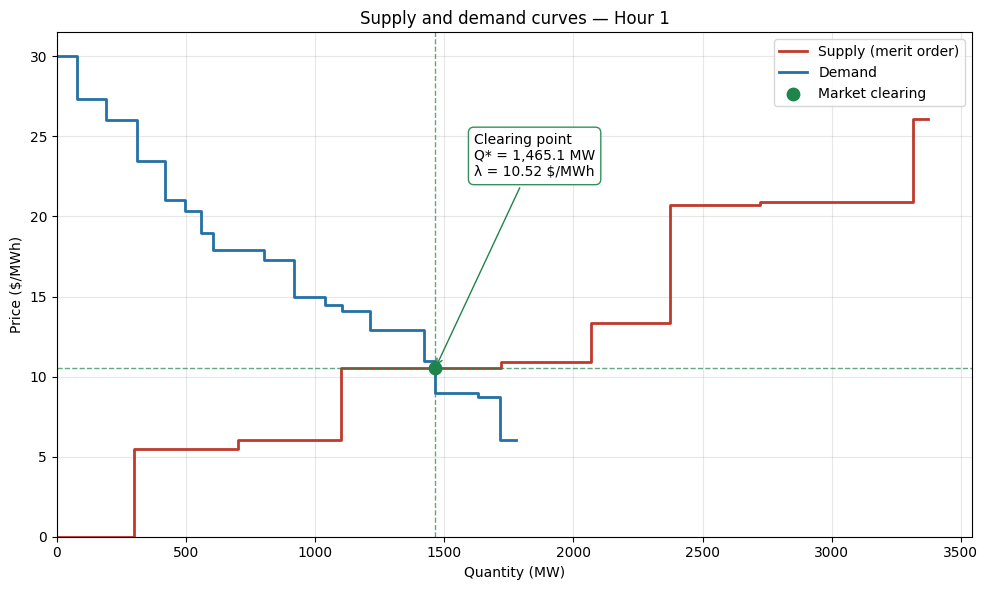

Total quantity cleared Q*: 1,465.064 MW
Market-clearing price λ: 10.52 $/MWh


In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Build stepwise merit-order curves from bids/offers and capacities
supply = generation_results.sort_values("offer ($/MWh)").copy()
supply["cum_qty"] = supply["Pmax (MW)"].cumsum()

demand = demand_results.sort_values("bid ($/MWh)", ascending=False).copy()
demand["cum_qty"] = demand["max demand (MW)"].cumsum()

def step_curve(cum_qty, price):
    """Return (x, y) arrays for a right-angle step supply/demand curve."""
    x = np.concatenate([[0.0], np.repeat(cum_qty.to_numpy(), 2)[:-1]])
    y = np.repeat(price.to_numpy(), 2)
    return x, y

sx, sy = step_curve(supply["cum_qty"], supply["offer ($/MWh)"])
dx, dy = step_curve(demand["cum_qty"], demand["bid ($/MWh)"])

Q_cleared = demand_results["cleared (MW)"].sum()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sx, sy, color="#c0392b", linewidth=2, label="Supply (merit order)")
ax.plot(dx, dy, color="#2471a3", linewidth=2, label="Demand")

# Intersection: market clearing (Q*, λ)
ax.scatter(
    [Q_cleared],
    [market_clearing_price],
    color="#1e8449",
    s=80,
    zorder=5,
    label="Market clearing",
)
ax.axvline(Q_cleared, color="#1e8449", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(market_clearing_price, color="#1e8449", linestyle="--", linewidth=1, alpha=0.7)

ax.annotate(
    f"Clearing point\nQ* = {Q_cleared:,.1f} MW\nλ = {market_clearing_price:.2f} $/MWh",
    xy=(Q_cleared, market_clearing_price),
    xytext=(Q_cleared + 150, market_clearing_price + 12),
    fontsize=10,
    arrowprops=dict(arrowstyle="->", color="#1e8449"),
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#1e8449", alpha=0.9),
)

ax.set_xlabel("Quantity (MW)")
ax.set_ylabel("Price ($/MWh)")
ax.set_title(f"Supply and demand curves — Hour {HOUR}")
ax.legend(loc="upper right")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total quantity cleared Q*: {Q_cleared:,.3f} MW")
print(f"Market-clearing price λ: {market_clearing_price:.2f} $/MWh")

In [37]:
# Producer profit: output × (MCP − offer price)
producer_profit = generation_results.copy()
producer_profit["profit ($)"] = producer_profit["output (MW)"] * (
    market_clearing_price - producer_profit["offer ($/MWh)"]
)

# Demand utility: power consumption × (bid price − MCP)
demand_utility = demand_results.copy()
demand_utility["utility ($)"] = demand_utility["cleared (MW)"] * (
    demand_utility["bid ($/MWh)"] - market_clearing_price
)

print(f"Market-clearing price (λ): {market_clearing_price:.2f} $/MWh\n")
print("Producer profits:")
display(producer_profit[["Unit #", "output (MW)", "offer ($/MWh)", "profit ($)"]])
print(f"Total producer profit: {producer_profit['profit ($)'].sum():,.2f} $\n")
print("Demand utilities:")
display(demand_utility[["Load #", "cleared (MW)", "bid ($/MWh)", "utility ($)"]])
print(f"Total demand utility: {demand_utility['utility ($)'].sum():,.2f} $")

Market-clearing price (λ): 10.52 $/MWh

Producer profits:


,Unit #,output (MW),offer ($/MWh),profit ($)
0,1,0.000000,13.32,-0.0
1,2,0.000000,13.32,-0.0
2,3,0.000000,20.70,-0.0
3,4,0.000000,20.93,-0.0
4,5,0.000000,26.11,-0.0
5,6,0.000000,10.52,0.0
6,7,155.000000,10.52,0.0
7,8,400.000000,6.02,1800.0
8,9,400.000000,5.47,2020.0
9,10,300.000000,0.00,3156.0


Total producer profit: 6,976.00 $

Demand utilities:


,Load #,cleared (MW),bid ($/MWh),utility ($)
0,1,67.481730,14.50,268.577285
1,2,0.000000,6.02,-0.000000
2,3,111.877605,27.32,1879.543764
3,4,46.171710,18.94,388.765798
4,5,44.395875,11.00,21.310020
5,6,0.000000,8.72,-0.000000
6,7,78.136740,30.00,1522.103695
7,8,106.550100,23.46,1378.758294
8,9,108.325935,14.10,387.806847
9,10,120.756780,15.00,540.990374


Total demand utility: 12,416.71 $


In [38]:
# KKT verification of the market-clearing price λ
#
# Stationarity (from the SW Lagrangian with balance Σ p_D − Σ p_G = 0 : λ):
#   Demand:     U_d − λ − μ_d^max + μ_d^min = 0
#   Generation: −C_g + λ − μ_g^max + μ_g^min = 0
# with μ ≥ 0 and complementary slackness on the capacity bounds.

tol = 1e-4
lam = market_clearing_price

kkt_demand_rows = []
for _, r in demand_results.iterrows():
    d = int(r["Load #"])
    p = float(r["cleared (MW)"])
    Pbar = float(r["max demand (MW)"])
    Ud = float(r["bid ($/MWh)"])

    if p <= tol:
        # at lower bound: μ_max = 0 ⇒ μ_min = λ − U_d ≥ 0  ⇔  U_d ≤ λ
        mu_min, mu_max = lam - Ud, 0.0
        regime = "p = 0"
    elif abs(p - Pbar) <= tol:
        # at upper bound: μ_min = 0 ⇒ μ_max = U_d − λ ≥ 0  ⇔  U_d ≥ λ
        mu_min, mu_max = 0.0, Ud - lam
        regime = "p = P̄"
    else:
        # interior: μ_min = μ_max = 0 ⇒ U_d = λ
        mu_min, mu_max = 0.0, 0.0
        regime = "0 < p < P̄"

    stationarity = Ud - lam - mu_max + mu_min
    cs_min = mu_min * p
    cs_max = mu_max * (Pbar - p)
    dual_ok = (mu_min >= -tol) and (mu_max >= -tol)
    kkt_ok = (
        abs(stationarity) <= tol
        and abs(cs_min) <= tol
        and abs(cs_max) <= tol
        and dual_ok
    )

    kkt_demand_rows.append(
        {
            "Load #": d,
            "regime": regime,
            "U_d": Ud,
            "p_D": p,
            "μ_min": mu_min,
            "μ_max": mu_max,
            "stationarity": stationarity,
            "KKT ok": kkt_ok,
        }
    )

kkt_gen_rows = []
for _, r in generation_results.iterrows():
    g = int(r["Unit #"])
    p = float(r["output (MW)"])
    Pbar = float(r["Pmax (MW)"])
    Cg = float(r["offer ($/MWh)"])

    if p <= tol:
        # at lower bound: μ_max = 0 ⇒ μ_min = C_g − λ ≥ 0  ⇔  C_g ≥ λ
        mu_min, mu_max = Cg - lam, 0.0
        regime = "p = 0"
    elif abs(p - Pbar) <= tol:
        # at upper bound: μ_min = 0 ⇒ μ_max = λ − C_g ≥ 0  ⇔  C_g ≤ λ
        mu_min, mu_max = 0.0, lam - Cg
        regime = "p = P̄"
    else:
        # interior (marginal unit): μ_min = μ_max = 0 ⇒ C_g = λ
        mu_min, mu_max = 0.0, 0.0
        regime = "0 < p < P̄"

    stationarity = -Cg + lam - mu_max + mu_min
    cs_min = mu_min * p
    cs_max = mu_max * (Pbar - p)
    dual_ok = (mu_min >= -tol) and (mu_max >= -tol)
    kkt_ok = (
        abs(stationarity) <= tol
        and abs(cs_min) <= tol
        and abs(cs_max) <= tol
        and dual_ok
    )

    kkt_gen_rows.append(
        {
            "Unit #": g,
            "regime": regime,
            "C_g": Cg,
            "p_G": p,
            "μ_min": mu_min,
            "μ_max": mu_max,
            "stationarity": stationarity,
            "KKT ok": kkt_ok,
        }
    )

kkt_demand = pd.DataFrame(kkt_demand_rows)
kkt_generation = pd.DataFrame(kkt_gen_rows)

# Power balance primal feasibility
balance_residual = demand_results["cleared (MW)"].sum() - generation_results["output (MW)"].sum()

print(f"Market-clearing price λ = {lam:.4f} $/MWh\n")
print("KKT — demands (U_d − λ − μ_max + μ_min = 0):")
display(kkt_demand)
print("KKT — generators (−C_g + λ − μ_max + μ_min = 0):")
display(kkt_generation)

all_ok = (
    kkt_demand["KKT ok"].all()
    and kkt_generation["KKT ok"].all()
    and abs(balance_residual) <= tol
)
print(f"\nPower-balance residual: {balance_residual:.6e} MW")
print(
    "KKT verification:",
    "PASSED — λ is consistent with the KKT conditions."
    if all_ok
    else "FAILED — check rows with KKT ok = False.",
)

Market-clearing price λ = 10.5200 $/MWh

KKT — demands (U_d − λ − μ_max + μ_min = 0):


,Load #,regime,U_d,p_D,μ_min,μ_max,stationarity,KKT ok
0,1,p = P̄,14.50,67.481730,0.00,3.98,0.0,True
1,2,p = 0,6.02,0.000000,4.50,0.00,0.0,True
2,3,p = P̄,27.32,111.877605,0.00,16.80,0.0,True
3,4,p = P̄,18.94,46.171710,0.00,8.42,0.0,True
4,5,p = P̄,11.00,44.395875,0.00,0.48,0.0,True
5,6,p = 0,8.72,0.000000,1.80,0.00,0.0,True
6,7,p = P̄,30.00,78.136740,0.00,19.48,0.0,True
7,8,p = P̄,23.46,106.550100,0.00,12.94,0.0,True
8,9,p = P̄,14.10,108.325935,0.00,3.58,0.0,True
9,10,p = P̄,15.00,120.756780,0.00,4.48,0.0,True


KKT — generators (−C_g + λ − μ_max + μ_min = 0):


,Unit #,regime,C_g,p_G,μ_min,μ_max,stationarity,KKT ok
0,1,p = 0,13.32,0.000000,2.80,0.00,0.0,True
1,2,p = 0,13.32,0.000000,2.80,0.00,0.0,True
2,3,p = 0,20.70,0.000000,10.18,0.00,0.0,True
3,4,p = 0,20.93,0.000000,10.41,0.00,0.0,True
4,5,p = 0,26.11,0.000000,15.59,0.00,0.0,True
5,6,p = 0,10.52,0.000000,0.00,0.00,0.0,True
6,7,p = P̄,10.52,155.000000,0.00,0.00,0.0,True
7,8,p = P̄,6.02,400.000000,0.00,4.50,0.0,True
8,9,p = P̄,5.47,400.000000,0.00,5.05,0.0,True
9,10,p = P̄,0.00,300.000000,0.00,10.52,0.0,True



Power-balance residual: 0.000000e+00 MW
KKT verification: PASSED — λ is consistent with the KKT conditions.


# STEP 2: Copper-Plate, Multiple Hours

In [39]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

# ---------------------------------------------------------------------------
# Synthetic 24-hour expansion of demand bids and generator energy offers.
# Hour 1 keeps the original values; other hours follow a diurnal price pattern
# (cheap overnight, expensive evening peak). Each hour is calibrated so the
# copper-plate market clears with roughly 2–5 unsatisfied demand bids.
# ---------------------------------------------------------------------------

rng = np.random.default_rng(42)

loads = demand_bids["Load #"].tolist()
units = generators_data["Unit #"].tolist()
Pmax = generators_data.set_index("Unit #")["Pmax_i (MW)"].to_dict()
base_U = demand_bids.set_index("Load #")["Synthetic demand bid ($/MWh)"].astype(float).to_dict()
base_C = generators_costs.set_index("Unit #")["C_i ($/MWh)"].astype(float).to_dict()
load_meta = demand_bids.set_index("Load #")[["Node", "% System Load"]]

# Diurnal intensity from the system load profile → price multiplier
sys_load = load_profile.set_index("Hour")["System demand (MW)"]
intensity = (sys_load - sys_load.min()) / (sys_load.max() - sys_load.min())
price_mult = 0.65 + 0.90 * (intensity ** 1.15)  # ~0.65 off-peak → ~1.55 peak
# Midday dip (hours 12–15): lower prices on average before the evening peak
price_mult.loc[12:15] *= 0.78
# Anchor hour 1 at multiplier 1 so the base bids/offers are unchanged there
price_mult = price_mult / float(price_mult.loc[1])


def _clear_hour(U, C, Pbar_D):
    m = gp.Model()
    m.Params.OutputFlag = 0
    p_D = m.addVars(loads, lb=0.0)
    p_G = m.addVars(units, lb=0.0)
    for d in loads:
        p_D[d].ub = Pbar_D[d]
    for g in units:
        p_G[g].ub = Pmax[g]

    # Maximising the social welfare    
    m.setObjective(
        gp.quicksum(U[d] * p_D[d] for d in loads)
        - gp.quicksum(C[g] * p_G[g] for g in units),
        GRB.MAXIMIZE,
    )
    bal = m.addConstr(
        gp.quicksum(p_D[d] for d in loads) - gp.quicksum(p_G[g] for g in units) == 0
    )
    m.optimize()
    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"Market did not clear (status={m.Status})")
    unsat = [d for d in loads if p_D[d].X <= 1e-6]
    return float(bal.Pi), float(sum(p_D[d].X for d in loads)), unsat


demand_bid_rows = []
generator_cost_rows = []
clearing_summary_rows = []

for hour in range(1, 25):
    mult = float(price_mult.loc[hour])
    demand_hour = units_demand.loc[units_demand["hour"] == hour].iloc[0]
    Pbar_D = {d: float(demand_hour[f"Load {d}"]) for d in loads}

    if hour == 1:
        U = {d: round(base_U[d], 2) for d in loads}
        C = {g: round(base_C[g], 2) for g in units}
    else:
        C = {
            g: 0.0
            if base_C[g] <= 1e-9
            else round(base_C[g] * mult * float(rng.uniform(0.97, 1.03)), 2)
            for g in units
        }
        # Hour-varying relative bid noise so different loads can be unserved
        U = {
            d: round(base_U[d] * mult * float(rng.uniform(0.88, 1.12)), 2)
            for d in loads
        }

    target_n = int(rng.integers(2, 6))  # 2–5 unsatisfied bids
    for _ in range(50):
        lam, Q, unsat = _clear_hour(U, C, Pbar_D)
        n = len(unsat)
        if 2 <= n <= 5:
            break
        ordered = sorted(loads, key=lambda d: U[d])
        if n < 2:
            for d in ordered[:target_n]:
                U[d] = round(max(min(U[d], lam) * 0.85 - 0.4, 0.01), 2)
            for g in units:
                if C[g] > 0:
                    C[g] = round(C[g] * 1.015, 2)
        else:  # n > 5: lift the highest unserved bids above λ
            for d in sorted(unsat, key=lambda d: U[d], reverse=True)[: n - target_n]:
                U[d] = round(max(U[d], lam) * 1.10 + 0.4, 2)
    else:
        lam, Q, unsat = _clear_hour(U, C, Pbar_D)

    clearing_summary_rows.append(
        {
            "hour": hour,
            "price multiplier": round(mult, 3),
            "MCP ($/MWh)": round(lam, 2),
            "cleared (MW)": round(Q, 3),
            "n unsatisfied": len(unsat),
            "unsatisfied loads": unsat,
        }
    )

    for d in loads:
        demand_bid_rows.append(
            {
                "Hour": hour,
                "Load #": d,
                "Node": int(load_meta.loc[d, "Node"]),
                "% System Load": (
                    pd.NA
                    if pd.isna(load_meta.loc[d, "% System Load"])
                    else float(load_meta.loc[d, "% System Load"])
                ),
                "Synthetic demand bid ($/MWh)": U[d],
            }
        )

    for g in units:
        row = generators_costs.loc[generators_costs["Unit #"] == g].iloc[0].to_dict()
        row["Hour"] = hour
        row["C_i ($/MWh)"] = C[g]
        generator_cost_rows.append(row)

demand_bids_24h = pd.DataFrame(demand_bid_rows)[
    ["Hour", "Load #", "Node", "% System Load", "Synthetic demand bid ($/MWh)"]
]
generators_costs_24h = pd.DataFrame(generator_cost_rows)
generators_costs_24h = generators_costs_24h[
    ["Hour"] + [c for c in generators_costs.columns if c in generators_costs_24h.columns]
]
clearing_summary_24h = pd.DataFrame(clearing_summary_rows)

# Persist synthetic datasets
out_bids = inputs_dir / "synthetic_demand_bids_24h.xlsx"
out_costs = inputs_dir / "synthetic_generator_costs_24h.xlsx"
demand_bids_24h.to_excel(out_bids, sheet_name="Demand Bids", index=False)
generators_costs_24h.to_excel(out_costs, sheet_name="Generator Costs", index=False)

print(f"Saved: {out_bids.name}, {out_costs.name}")
print(
    f"Unsatisfied bids per hour: "
    f"{clearing_summary_24h['n unsatisfied'].min()}–"
    f"{clearing_summary_24h['n unsatisfied'].max()}"
)
print(
    f"MCP range: "
    f"{clearing_summary_24h['MCP ($/MWh)'].min():.2f}–"
    f"{clearing_summary_24h['MCP ($/MWh)'].max():.2f} $/MWh"
)


Saved: synthetic_demand_bids_24h.xlsx, synthetic_generator_costs_24h.xlsx
Unsatisfied bids per hour: 3–4
MCP range: 8.58–25.89 $/MWh


In [40]:
import plotly.graph_objects as go

# Interactive supply & demand curves by hour (dropdown)
Pmax_map = generators_data.set_index("Unit #")["Pmax_i (MW)"].to_dict()


def _step_curve(cum_qty, price):
    x = np.concatenate([[0.0], np.repeat(np.asarray(cum_qty, dtype=float), 2)[:-1]])
    y = np.repeat(np.asarray(price, dtype=float), 2)
    return x, y


fig = go.Figure()
n_traces_per_hour = 3  # supply, demand, clearing point

for hour in range(1, 25):
    supply = (
        generators_costs_24h.loc[generators_costs_24h["Hour"] == hour, ["Unit #", "C_i ($/MWh)"]]
        .assign(**{"Pmax (MW)": lambda df: df["Unit #"].map(Pmax_map)})
        .sort_values("C_i ($/MWh)")
    )
    supply["cum_qty"] = supply["Pmax (MW)"].cumsum()

    demand = (
        demand_bids_24h.loc[
            demand_bids_24h["Hour"] == hour,
            ["Load #", "Synthetic demand bid ($/MWh)"],
        ]
        .copy()
    )
    demand_hour = units_demand.loc[units_demand["hour"] == hour].iloc[0]
    demand["max demand (MW)"] = demand["Load #"].map(lambda d: float(demand_hour[f"Load {d}"]))
    demand = demand.sort_values("Synthetic demand bid ($/MWh)", ascending=False)
    demand["cum_qty"] = demand["max demand (MW)"].cumsum()

    sx, sy = _step_curve(supply["cum_qty"], supply["C_i ($/MWh)"])
    dx, dy = _step_curve(demand["cum_qty"], demand["Synthetic demand bid ($/MWh)"])

    row = clearing_summary_24h.loc[clearing_summary_24h["hour"] == hour].iloc[0]
    Q_star = float(row["cleared (MW)"])
    lam = float(row["MCP ($/MWh)"])

    visible = hour == 1
    fig.add_trace(
        go.Scatter(
            x=sx, y=sy, mode="lines", name="Supply",
            line=dict(color="#c0392b", width=2),
            visible=visible, legendgroup="supply", showlegend=visible,
        )
    )
    fig.add_trace(
        go.Scatter(
            x=dx, y=dy, mode="lines", name="Demand",
            line=dict(color="#2471a3", width=2),
            visible=visible, legendgroup="demand", showlegend=visible,
        )
    )
    fig.add_trace(
        go.Scatter(
            x=[Q_star], y=[lam], mode="markers+text",
            name="Clearing (MCP)",
            marker=dict(color="#1e8449", size=12, symbol="diamond"),
            text=[f"Q*={Q_star:,.0f} MW<br>λ={lam:.2f} $/MWh"],
            textposition="top right",
            visible=visible, legendgroup="mcp", showlegend=visible,
        )
    )

buttons = []
for hour in range(1, 25):
    vis = [False] * (24 * n_traces_per_hour)
    start = (hour - 1) * n_traces_per_hour
    for k in range(n_traces_per_hour):
        vis[start + k] = True
    row = clearing_summary_24h.loc[clearing_summary_24h["hour"] == hour].iloc[0]
    buttons.append(
        dict(
            label=f"Hour {hour}",
            method="update",
            args=[
                {"visible": vis, "showlegend": vis},
                {
                    "title": (
                        f"Supply & demand — Hour {hour}  |  "
                        f"MCP λ = {row['MCP ($/MWh)']:.2f} $/MWh, "
                        f"Q* = {row['cleared (MW)']:,.1f} MW"
                    )
                },
            ],
        )
    )

row1 = clearing_summary_24h.loc[clearing_summary_24h["hour"] == 1].iloc[0]
fig.update_layout(
    title=(
        f"Supply & demand — Hour 1  |  "
        f"MCP λ = {row1['MCP ($/MWh)']:.2f} $/MWh, "
        f"Q* = {row1['cleared (MW)']:,.1f} MW"
    ),
    xaxis_title="Quantity (MW)",
    yaxis_title="Price ($/MWh)",
    template="plotly_white",
    height=520,
    margin=dict(t=80),
    updatemenus=[
        dict(
            active=0,
            buttons=buttons,
            direction="down",
            showactive=True,
            x=1.02,
            xanchor="left",
            y=1.0,
            yanchor="top",
            bgcolor="#f4f6f7",
            bordercolor="#bdc3c7",
        )
    ],
    annotations=[
        dict(
            text="Hour",
            x=1.02,
            xref="paper",
            y=1.08,
            yref="paper",
            showarrow=False,
            xanchor="left",
        )
    ],
)
fig.update_xaxes(rangemode="tozero")
fig.update_yaxes(rangemode="tozero")
fig.show()

In [41]:
# Total social welfare and producer profits over 24 hours
# SW_h = Σ_d U_{d,h} p_{d,h}^D − Σ_g C_{g,h} p_{g,h}^G
# Profit_{g,h} = p_{g,h}^G × (λ_h − C_{g,h})

def _int_float_dict(d):
    return {int(k): float(v) for k, v in d.items()}

Pmax_map = _int_float_dict(generators_data.set_index("Unit #")["Pmax_i (MW)"].to_dict())
loads = sorted(int(x) for x in demand_bids_24h["Load #"].unique())
units = sorted(int(x) for x in generators_costs_24h["Unit #"].unique())

sw_rows = []
profit_rows = []
for hour in range(1, 25):
    U = _int_float_dict(
        demand_bids_24h.loc[demand_bids_24h["Hour"] == hour]
        .set_index("Load #")["Synthetic demand bid ($/MWh)"]
        .to_dict()
    )
    C = _int_float_dict(
        generators_costs_24h.loc[generators_costs_24h["Hour"] == hour]
        .set_index("Unit #")["C_i ($/MWh)"]
        .to_dict()
    )
    demand_hour = units_demand.loc[units_demand["hour"] == hour].iloc[0]
    Pbar_D = {d: float(demand_hour[f"Load {d}"]) for d in loads}

    m = gp.Model()
    m.Params.OutputFlag = 0
    p_D = m.addVars(loads, lb=0.0)
    p_G = m.addVars(units, lb=0.0)
    for d in loads:
        p_D[d].ub = Pbar_D[d]
    for g in units:
        p_G[g].ub = Pmax_map[g]

    m.setObjective(
        gp.quicksum(U[d] * p_D[d] for d in loads)
        - gp.quicksum(C[g] * p_G[g] for g in units),
        GRB.MAXIMIZE,
    )
    balance = m.addConstr(
        gp.quicksum(p_D[d] for d in loads) - gp.quicksum(p_G[g] for g in units) == 0
    )
    m.optimize()
    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"Hour {hour} did not clear (status={m.Status})")

    mcp = balance.Pi  # λ_h
    sw_rows.append({"hour": hour, "social welfare ($)": m.ObjVal, "MCP ($/MWh)": mcp})
    for g in units:
        output = p_G[g].X
        profit_rows.append(
            {
                "hour": hour,
                "Unit #": g,
                "output (MW)": output,
                "offer ($/MWh)": C[g],
                "MCP ($/MWh)": mcp,
                "profit ($)": output * (mcp - C[g]),
            }
        )

social_welfare_24h = pd.DataFrame(sw_rows)
total_social_welfare = social_welfare_24h["social welfare ($)"].sum()

producer_profit_24h = pd.DataFrame(profit_rows)
producer_profit_totals = (
    producer_profit_24h.groupby("Unit #", as_index=False)["profit ($)"]
    .sum()
    .rename(columns={"profit ($)": "total profit ($)"})
)
total_producer_profit = producer_profit_totals["total profit ($)"].sum()

print(f"Total social welfare (24 h): {total_social_welfare:,.2f} $")
display(social_welfare_24h)

print(f"\nTotal profit of each producer (24 h):")
display(producer_profit_totals)
print(f"Sum of producer profits (24 h): {total_producer_profit:,.2f} $")


Total social welfare (24 h): 770,726.76 $


,hour,social welfare ($),MCP ($/MWh)
0,1,19392.709353,10.52
1,2,17192.383752,9.44
2,3,15321.818903,8.71
3,4,14309.015336,8.58
4,5,15267.268157,8.75
5,6,15105.946952,8.61
6,7,24313.508393,12.42
7,8,33519.615833,16.71
8,9,46235.135310,21.05
9,10,45638.087550,20.77



Total profit of each producer (24 h):


,Unit #,total profit ($)
0,1,0.00
1,2,0.00
2,3,0.00
3,4,0.00
4,5,0.00
5,6,2583.85
6,7,3098.45
7,8,68172.00
8,9,76028.00
9,10,112077.00


Sum of producer profits (24 h): 271,050.40 $


## Adding the battery

In [42]:
# Add battery to the system (offers as a generator and bids as a demand)
BATTERY_UNIT = int(generators_data["Unit #"].max()) + 1  # 13
BATTERY_LOAD = int(demand_bids["Load #"].max()) + 1  # 18
BATTERY_NODE = 1
BATTERY_CAPACITY_MW = 200.0

# ---------------------------------------------------------------------------
# Battery as an INTERTEMPORAL resource (not a normal single-hour unit/load)
#
# Feasible / economic behavior in hour t depends on:
#   - SoC e_{t-1} (and capacity E), and
#   - charge/discharge in all other hours (SoC couples the 24 h horizon).
#
# Bid/offer quantities are limited by physics (enforced in the 24 h clear):
#   p_t^{ch}  ≤ min(P^{ch},  (E − e_{t-1}) / η^{ch})   # only free headroom
#   p_t^{dis} ≤ min(P^{dis}, η^{dis} e_{t-1})          # only energy stored
#   cannot charge and discharge in the same hour
# ---------------------------------------------------------------------------
BATTERY_P_CH = BATTERY_CAPACITY_MW   # P^{ch}  (MW)
BATTERY_P_DIS = BATTERY_CAPACITY_MW  # P^{dis} (MW)
BATTERY_E = BATTERY_CAPACITY_MW      # E (MWh)  [note: with P=200 MW this is 1 h of storage, not 4 h]
BATTERY_ETA_CH = 0.90                # η^{ch}
BATTERY_ETA_DIS = 0.95               # η^{dis}
BATTERY_E0 = 0.0                     # e_0: start empty

# Register discharge side in generators_data (offer interface only).
# Do NOT interpret this row as "Unit 13 can be scheduled from hour-t offers alone."
generators_data = pd.concat(
    [
        generators_data,
        pd.DataFrame(
            [
                {
                    "Unit #": BATTERY_UNIT,
                    "Node": BATTERY_NODE,
                    "Pmax_i (MW)": BATTERY_P_DIS,
                    "Pmin_i (MW)": 0.0,
                    "R+_i (MW)": BATTERY_P_DIS,
                    "R-_i (MW)": BATTERY_P_DIS,
                    "RU_i (MW/h)": BATTERY_P_DIS,
                    "RD_i (MW/h)": BATTERY_P_DIS,
                    "UT (h)": 0,
                    "DT (h)": 0,
                }
            ]
        ),
    ],
    ignore_index=True,
)

# generators_costs — 0 for all columns except Unit #
battery_costs = {col: 0.0 for col in generators_costs.columns}
battery_costs["Unit #"] = BATTERY_UNIT
generators_costs = pd.concat(
    [generators_costs, pd.DataFrame([battery_costs])],
    ignore_index=True,
)

# demand_bids — battery can also buy (bid = 0 $/MWh; % system load N.A.)
demand_bids = pd.concat(
    [
        demand_bids,
        pd.DataFrame(
            [
                {
                    "Load #": BATTERY_LOAD,
                    "Node": BATTERY_NODE,
                    "% System Load": pd.NA,
                    "Synthetic demand bid ($/MWh)": 0.0,
                }
            ]
        ),
    ],
    ignore_index=True,
)

# units_demand — rated charge power only (NOT a 200 MW demand bid every hour).
# Actual bid qty each hour is min(P^{ch}, (E − e_{t-1}) / η^{ch}) in the 24 h clear.
units_demand[f"Load {BATTERY_LOAD}"] = BATTERY_P_CH

print(
    f"Battery added as Unit #{BATTERY_UNIT} and Load #{BATTERY_LOAD} (Node {BATTERY_NODE})"
)
print(
    f"Limits: rated 0 ≤ p^ch ≤ {BATTERY_P_CH:.0f} MW, 0 ≤ p^dis ≤ {BATTERY_P_DIS:.0f} MW; "
    f"0 ≤ e ≤ {BATTERY_E:.0f} MWh; η^ch={BATTERY_ETA_CH}, η^dis={BATTERY_ETA_DIS}, e0={BATTERY_E0:.0f} MWh; "
    f"bid/offer also capped by SoC headroom / stored energy; no simultaneous ch/dis"
)


Battery added as Unit #13 and Load #18 (Node 1)
Limits: rated 0 ≤ p^ch ≤ 200 MW, 0 ≤ p^dis ≤ 200 MW; 0 ≤ e ≤ 200 MWh; η^ch=0.9, η^dis=0.95, e0=0 MWh; bid/offer also capped by SoC headroom / stored energy; no simultaneous ch/dis


/var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/ipykernel_70117/684728118.py:60: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  demand_bids = pd.concat(


## MCP, Social Welfare, and profit with the battery

In [43]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

# ---------------------------------------------------------------------------
# Synthetic 24-hour expansion of demand bids and generator energy offers.
# Hour 1 keeps the original values; other hours follow a diurnal price pattern
# (cheap overnight, expensive evening peak). Each hour is calibrated so the
# copper-plate market clears with roughly 2–5 unsatisfied demand bids.
#
# Battery (Load #BATTERY_LOAD / Unit #BATTERY_UNIT) is kept out of the
# hour-by-hour bid calibration, then included in a multi-period clearing.
# Intertemporal physics (bid/offer limited by start-of-hour SoC):
#   0 ≤ p_t^{ch}  ≤ min(P^{ch},  (E − e_{t-1}) / η^{ch})
#   0 ≤ p_t^{dis} ≤ min(P^{dis}, η^{dis} e_{t-1})
#   0 ≤ e_t ≤ E
#   e_t = e_{t-1} + η^{ch} p_t^{ch} − p_t^{dis} / η^{dis}
#   cannot charge and discharge in the same hour
# ---------------------------------------------------------------------------

rng = np.random.default_rng(42)

loads = demand_bids["Load #"].tolist()
units = generators_data["Unit #"].tolist()
# Conventional participants only (battery SoC couples hours → separate multi-period clear)
loads_cal = [d for d in loads if d != BATTERY_LOAD]
units_cal = [g for g in units if g != BATTERY_UNIT]

Pmax = generators_data.set_index("Unit #")["Pmax_i (MW)"].to_dict()
base_U = demand_bids.set_index("Load #")["Synthetic demand bid ($/MWh)"].astype(float).to_dict()
base_C = generators_costs.set_index("Unit #")["C_i ($/MWh)"].astype(float).to_dict()
load_meta = demand_bids.set_index("Load #")[["Node", "% System Load"]]

# Diurnal intensity from the system load profile → price multiplier
sys_load = load_profile.set_index("Hour")["System demand (MW)"]
intensity = (sys_load - sys_load.min()) / (sys_load.max() - sys_load.min())
price_mult = 0.65 + 0.90 * (intensity ** 1.15)  # ~0.65 off-peak → ~1.55 peak
# Midday dip (hours 12–15): lower prices on average before the evening peak
price_mult.loc[12:15] *= 0.78
# Anchor hour 1 at multiplier 1 so the base bids/offers are unchanged there
price_mult = price_mult / float(price_mult.loc[1])


def _clear_hour(U, C, Pbar_D, loads_h, units_h):
    """Single-hour copper-plate clear (no battery / no SoC)."""
    m = gp.Model()
    m.Params.OutputFlag = 0
    p_D = m.addVars(loads_h, lb=0.0)
    p_G = m.addVars(units_h, lb=0.0)
    for d in loads_h:
        p_D[d].ub = Pbar_D[d]
    for g in units_h:
        p_G[g].ub = Pmax[g]

    m.setObjective(
        gp.quicksum(U[d] * p_D[d] for d in loads_h)
        - gp.quicksum(C[g] * p_G[g] for g in units_h),
        GRB.MAXIMIZE,
    )
    bal = m.addConstr(
        gp.quicksum(p_D[d] for d in loads_h) - gp.quicksum(p_G[g] for g in units_h) == 0
    )
    m.optimize()
    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"Market did not clear (status={m.Status})")
    unsat = [d for d in loads_h if p_D[d].X <= 1e-6]
    return float(bal.Pi), float(sum(p_D[d].X for d in loads_h)), unsat


demand_bid_rows = []
generator_cost_rows = []
U_by_hour = {}
C_by_hour = {}
Pbar_by_hour = {}

for hour in range(1, 25):
    mult = float(price_mult.loc[hour])
    demand_hour = units_demand.loc[units_demand["hour"] == hour].iloc[0]
    Pbar_D = {d: float(demand_hour[f"Load {d}"]) for d in loads}
    Pbar_by_hour[hour] = Pbar_D

    if hour == 1:
        U = {d: round(base_U[d], 2) for d in loads}
        C = {g: round(base_C[g], 2) for g in units}
    else:
        C = {
            g: 0.0
            if base_C[g] <= 1e-9
            else round(base_C[g] * mult * float(rng.uniform(0.97, 1.03)), 2)
            for g in units
        }
        U = {
            d: round(base_U[d] * mult * float(rng.uniform(0.88, 1.12)), 2)
            for d in loads
        }

    # Battery always bids/offers at 0 $/MWh
    U[BATTERY_LOAD] = 0.0
    C[BATTERY_UNIT] = 0.0

    # Calibrate unsatisfied conventional bids (battery excluded: SoC couples hours)
    target_n = int(rng.integers(2, 6))  # 2–5 unsatisfied bids
    for _ in range(50):
        lam, Q, unsat = _clear_hour(U, C, Pbar_D, loads_cal, units_cal)
        n = len(unsat)
        if 2 <= n <= 5:
            break
        ordered = sorted(loads_cal, key=lambda d: U[d])
        if n < 2:
            for d in ordered[:target_n]:
                U[d] = round(max(min(U[d], lam) * 0.85 - 0.4, 0.01), 2)
            for g in units_cal:
                if C[g] > 0:
                    C[g] = round(C[g] * 1.015, 2)
        else:  # n > 5: lift the highest unserved bids above λ
            for d in sorted(unsat, key=lambda d: U[d], reverse=True)[: n - target_n]:
                U[d] = round(max(U[d], lam) * 1.10 + 0.4, 2)
    else:
        lam, Q, unsat = _clear_hour(U, C, Pbar_D, loads_cal, units_cal)

    U[BATTERY_LOAD] = 0.0
    C[BATTERY_UNIT] = 0.0
    U_by_hour[hour] = U
    C_by_hour[hour] = C

    for d in loads:
        demand_bid_rows.append(
            {
                "Hour": hour,
                "Load #": d,
                "Node": int(load_meta.loc[d, "Node"]),
                "% System Load": (
                    pd.NA
                    if pd.isna(load_meta.loc[d, "% System Load"])
                    else float(load_meta.loc[d, "% System Load"])
                ),
                "Synthetic demand bid ($/MWh)": U[d],
            }
        )

    for g in units:
        row = generators_costs.loc[generators_costs["Unit #"] == g].iloc[0].to_dict()
        row["Hour"] = hour
        row["C_i ($/MWh)"] = C[g]
        generator_cost_rows.append(row)

demand_bids_24h = pd.DataFrame(demand_bid_rows)[
    ["Hour", "Load #", "Node", "% System Load", "Synthetic demand bid ($/MWh)"]
]
generators_costs_24h = pd.DataFrame(generator_cost_rows)
generators_costs_24h = generators_costs_24h[
    ["Hour"] + [c for c in generators_costs.columns if c in generators_costs_24h.columns]
]

# ---------------------------------------------------------------------------
# Multi-period copper-plate clearing — battery as SoC-limited storage
# (NOT a 200 MW load/unit bid). Charge/discharge qty each hour is capped by
# rated power AND start-of-hour SoC (with efficiencies).
# ---------------------------------------------------------------------------
hours = list(range(1, 25))
loads_mkt = list(loads_cal)   # conventional demand only
units_mkt = list(units_cal)   # conventional generation only

m24 = gp.Model("copper_plate_24h_battery")
m24.Params.OutputFlag = 0

p_D = m24.addVars(loads_mkt, hours, lb=0.0, name="p_D")
p_G = m24.addVars(units_mkt, hours, lb=0.0, name="p_G")
# Storage interfaces (physics-limited — not full-capacity market bids)
p_ch = m24.addVars(hours, lb=0.0, ub=BATTERY_P_CH, name="p_ch")
p_dis = m24.addVars(hours, lb=0.0, ub=BATTERY_P_DIS, name="p_dis")
e = m24.addVars(hours, lb=0.0, ub=BATTERY_E, name="e")
u_ch = m24.addVars(hours, vtype=GRB.BINARY, name="u_ch")  # 1=charge, 0=discharge

for h in hours:
    for d in loads_mkt:
        p_D[d, h].ub = Pbar_by_hour[h][d]
    for g in units_mkt:
        p_G[g, h].ub = Pmax[g]

m24.setObjective(
    gp.quicksum(U_by_hour[h][d] * p_D[d, h] for h in hours for d in loads_mkt)
    - gp.quicksum(C_by_hour[h][g] * p_G[g, h] for h in hours for g in units_mkt),
    GRB.MAXIMIZE,
)

balance = {}
for h in hours:
    # Demand + charge = generation + discharge
    balance[h] = m24.addConstr(
        gp.quicksum(p_D[d, h] for d in loads_mkt) + p_ch[h]
        - gp.quicksum(p_G[g, h] for g in units_mkt) - p_dis[h]
        == 0,
        name=f"balance_{h}",
    )

e_prev = BATTERY_E0
for h in hours:
    # SoC balance
    m24.addConstr(
        e[h]
        == e_prev + BATTERY_ETA_CH * p_ch[h] - p_dis[h] / BATTERY_ETA_DIS,
        name=f"soc_{h}",
    )
    # Bid qty ≤ free headroom: η^{ch} p^{ch} ≤ E − e_{t-1}
    m24.addConstr(
        BATTERY_ETA_CH * p_ch[h] <= BATTERY_E - e_prev,
        name=f"bid_headroom_{h}",
    )
    # Offer qty ≤ stored energy: p^{dis} ≤ η^{dis} e_{t-1}
    m24.addConstr(
        p_dis[h] <= BATTERY_ETA_DIS * e_prev,
        name=f"offer_stored_{h}",
    )
    # Not both modes in the same hour
    m24.addConstr(p_ch[h] <= BATTERY_P_CH * u_ch[h], name=f"mode_ch_{h}")
    m24.addConstr(p_dis[h] <= BATTERY_P_DIS * (1 - u_ch[h]), name=f"mode_dis_{h}")
    e_prev = e[h]

m24.optimize()
if m24.Status != GRB.OPTIMAL:
    raise RuntimeError(f"24 h market with battery did not clear (status={m24.Status})")

# MIP has no duals — LP with binaries fixed for MCP
m24_lp = m24.fixed()
m24_lp.Params.OutputFlag = 0
m24_lp.optimize()
if m24_lp.Status != GRB.OPTIMAL:
    raise RuntimeError(f"LP re-solve for duals failed (status={m24_lp.Status})")

clearing_summary_rows = []
e_start = float(BATTERY_E0)
for h in hours:
    bought = float(p_ch[h].X)
    sold = float(p_dis[h].X)
    # Physical bid/offer caps from SoC at the start of the hour
    bid_cap = min(BATTERY_P_CH, (BATTERY_E - e_start) / BATTERY_ETA_CH)
    offer_cap = min(BATTERY_P_DIS, BATTERY_ETA_DIS * e_start)
    Q = sum(p_D[d, h].X for d in loads_mkt) + bought
    unsat = [d for d in loads_mkt if p_D[d, h].X <= 1e-6]
    clearing_summary_rows.append(
        {
            "hour": h,
            "price multiplier": round(float(price_mult.loc[h]), 3),
            "MCP ($/MWh)": round(m24_lp.getConstrByName(f"balance_{h}").Pi, 2),
            "cleared (MW)": round(Q, 3),
            "n unsatisfied": len(unsat),
            "unsatisfied loads": unsat,
            "battery bid cap (MW)": round(bid_cap, 3),
            "battery offer cap (MW)": round(offer_cap, 3),
            "battery bought (MW)": round(bought, 3),
            "battery sold (MW)": round(sold, 3),
            "battery SoC (MWh)": round(float(e[h].X), 3),
        }
    )
    e_start = float(e[h].X)

clearing_summary_24h = pd.DataFrame(clearing_summary_rows)

# Persist synthetic datasets (conventional + battery price rows; qty caps are SoC-based above)
out_bids = inputs_dir / "synthetic_demand_bids_24h.xlsx"
out_costs = inputs_dir / "synthetic_generator_costs_24h.xlsx"
demand_bids_24h.to_excel(out_bids, sheet_name="Demand Bids", index=False)
generators_costs_24h.to_excel(out_costs, sheet_name="Generator Costs", index=False)

print(f"Saved: {out_bids.name}, {out_costs.name}")
print(
    f"Unsatisfied bids per hour: "
    f"{clearing_summary_24h['n unsatisfied'].min()}–"
    f"{clearing_summary_24h['n unsatisfied'].max()}"
)
print(
    f"MCP range: "
    f"{clearing_summary_24h['MCP ($/MWh)'].min():.2f}–"
    f"{clearing_summary_24h['MCP ($/MWh)'].max():.2f} $/MWh"
)
print(
    f"Battery SoC range: "
    f"{clearing_summary_24h['battery SoC (MWh)'].min():.1f}–"
    f"{clearing_summary_24h['battery SoC (MWh)'].max():.1f} MWh "
    f"(E={BATTERY_E:.0f})"
)
print(
    "Battery bid/offer caps are SoC-limited (see columns); "
    "cleared bought/sold never exceed those caps."
)
display(clearing_summary_24h)


Saved: synthetic_demand_bids_24h.xlsx, synthetic_generator_costs_24h.xlsx
Unsatisfied bids per hour: 3–4
MCP range: 8.58–22.84 $/MWh
Battery SoC range: 0.0–200.0 MWh (E=200)
Battery bid/offer caps are SoC-limited (see columns); cleared bought/sold never exceed those caps.


,hour,price multiplier,MCP ($/MWh),cleared (MW),n unsatisfied,unsatisfied loads,battery bid cap (MW),battery offer cap (MW),battery bought (MW),battery sold (MW),battery SoC (MWh)
0,1,1.000,10.52,1465.064,3,"[2, 6, 11]",200.000,0.000,0.000,0.000,0.000
1,2,0.904,9.44,1377.597,3,"[2, 6, 11]",200.000,0.000,0.000,0.000,0.000
2,3,0.841,8.69,1311.997,3,"[2, 6, 11]",200.000,0.000,0.000,0.000,0.000
3,4,0.825,8.65,1251.036,4,"[2, 5, 6, 11]",200.000,0.000,0.000,0.000,0.000
4,5,0.825,8.58,1490.131,3,"[2, 6, 11]",200.000,0.000,200.000,0.000,180.000
5,6,0.841,8.64,1334.220,3,"[2, 6, 11]",22.222,171.000,22.222,0.000,200.000
6,7,1.185,12.59,1569.096,4,"[2, 5, 6, 11]",0.000,190.000,0.000,0.000,200.000
7,8,1.532,16.94,1880.530,3,"[2, 6, 11]",0.000,190.000,0.000,0.000,200.000
8,9,1.810,19.94,2077.329,3,"[2, 6, 11]",0.000,190.000,0.000,7.329,192.285
9,10,1.841,19.94,2099.196,3,"[2, 6, 11]",8.572,182.671,0.000,182.671,0.000


In [44]:
import plotly.graph_objects as go

# Interactive supply & demand curves by hour (dropdown).
# Battery is NOT drawn as a full-Pmax bid and full-Pmax offer at $0.
# It appears only on the active side, at its SoC-limited cleared quantity.
Pmax_map = generators_data.set_index("Unit #")["Pmax_i (MW)"].to_dict()


def _step_curve(cum_qty, price):
    x = np.concatenate([[0.0], np.repeat(np.asarray(cum_qty, dtype=float), 2)[:-1]])
    y = np.repeat(np.asarray(price, dtype=float), 2)
    return x, y


fig = go.Figure()
n_traces_per_hour = 3  # supply, demand, clearing point

for hour in range(1, 25):
    row = clearing_summary_24h.loc[clearing_summary_24h["hour"] == hour].iloc[0]
    bat_buy = float(row["battery bought (MW)"])
    bat_sell = float(row["battery sold (MW)"])

    # Conventional generators only (+ battery discharge if cleared this hour)
    supply = (
        generators_costs_24h.loc[
            (generators_costs_24h["Hour"] == hour)
            & (generators_costs_24h["Unit #"] != BATTERY_UNIT),
            ["Unit #", "C_i ($/MWh)"],
        ]
        .assign(**{"Pmax (MW)": lambda df: df["Unit #"].map(Pmax_map)})
        .copy()
    )
    if bat_sell > 1e-6:
        supply = pd.concat(
            [
                supply,
                pd.DataFrame(
                    [{"Unit #": BATTERY_UNIT, "C_i ($/MWh)": 0.0, "Pmax (MW)": bat_sell}]
                ),
            ],
            ignore_index=True,
        )
    supply = supply.sort_values("C_i ($/MWh)")
    supply["cum_qty"] = supply["Pmax (MW)"].cumsum()

    # Conventional loads only (+ battery charge if cleared this hour)
    demand = (
        demand_bids_24h.loc[
            (demand_bids_24h["Hour"] == hour) & (demand_bids_24h["Load #"] != BATTERY_LOAD),
            ["Load #", "Synthetic demand bid ($/MWh)"],
        ]
        .copy()
    )
    demand_hour = units_demand.loc[units_demand["hour"] == hour].iloc[0]
    demand["max demand (MW)"] = demand["Load #"].map(
        lambda d: float(demand_hour[f"Load {d}"])
    )
    if bat_buy > 1e-6:
        demand = pd.concat(
            [
                demand,
                pd.DataFrame(
                    [
                        {
                            "Load #": BATTERY_LOAD,
                            "Synthetic demand bid ($/MWh)": 0.0,
                            "max demand (MW)": bat_buy,
                        }
                    ]
                ),
            ],
            ignore_index=True,
        )
    demand = demand.sort_values("Synthetic demand bid ($/MWh)", ascending=False)
    demand["cum_qty"] = demand["max demand (MW)"].cumsum()

    sx, sy = _step_curve(supply["cum_qty"], supply["C_i ($/MWh)"])
    dx, dy = _step_curve(demand["cum_qty"], demand["Synthetic demand bid ($/MWh)"])

    Q_star = float(row["cleared (MW)"])
    lam = float(row["MCP ($/MWh)"])

    visible = hour == 1
    fig.add_trace(
        go.Scatter(
            x=sx, y=sy, mode="lines", name="Supply",
            line=dict(color="#c0392b", width=2),
            visible=visible, legendgroup="supply", showlegend=visible,
        )
    )
    fig.add_trace(
        go.Scatter(
            x=dx, y=dy, mode="lines", name="Demand",
            line=dict(color="#2471a3", width=2),
            visible=visible, legendgroup="demand", showlegend=visible,
        )
    )
    fig.add_trace(
        go.Scatter(
            x=[Q_star], y=[lam], mode="markers+text",
            name="Clearing (MCP)",
            marker=dict(color="#1e8449", size=12, symbol="diamond"),
            text=[f"Q*={Q_star:,.0f} MW<br>λ={lam:.2f} $/MWh"],
            textposition="top right",
            visible=visible, legendgroup="mcp", showlegend=visible,
        )
    )

buttons = []
for hour in range(1, 25):
    vis = [False] * (24 * n_traces_per_hour)
    start = (hour - 1) * n_traces_per_hour
    for k in range(n_traces_per_hour):
        vis[start + k] = True
    row = clearing_summary_24h.loc[clearing_summary_24h["hour"] == hour].iloc[0]
    buttons.append(
        dict(
            label=f"Hour {hour}",
            method="update",
            args=[
                {"visible": vis, "showlegend": vis},
                {
                    "title": (
                        f"Supply & demand — Hour {hour}  |  "
                        f"MCP λ = {row['MCP ($/MWh)']:.2f} $/MWh, "
                        f"Q* = {row['cleared (MW)']:,.1f} MW"
                    )
                },
            ],
        )
    )

row1 = clearing_summary_24h.loc[clearing_summary_24h["hour"] == 1].iloc[0]
fig.update_layout(
    title=(
        f"Supply & demand — Hour 1  |  "
        f"MCP λ = {row1['MCP ($/MWh)']:.2f} $/MWh, "
        f"Q* = {row1['cleared (MW)']:,.1f} MW"
    ),
    xaxis_title="Quantity (MW)",
    yaxis_title="Price ($/MWh)",
    template="plotly_white",
    height=520,
    margin=dict(t=80),
    updatemenus=[
        dict(
            active=0,
            buttons=buttons,
            direction="down",
            showactive=True,
            x=1.02,
            xanchor="left",
            y=1.0,
            yanchor="top",
            bgcolor="#f4f6f7",
            bordercolor="#bdc3c7",
        )
    ],
    annotations=[
        dict(
            text="Hour",
            x=1.02,
            xref="paper",
            y=1.08,
            yref="paper",
            showarrow=False,
            xanchor="left",
        )
    ],
)
fig.update_xaxes(rangemode="tozero")
fig.update_yaxes(rangemode="tozero")
fig.show()


In [45]:
# Total social welfare and producer profits over 24 hours (with battery SoC)
# Battery is a SoC-limited storage resource (p_ch / p_dis), not a 200 MW bid/offer.
#   p_t^{ch}  ≤ min(P^{ch},  (E − e_{t-1}) / η^{ch})
#   p_t^{dis} ≤ min(P^{dis}, η^{dis} e_{t-1})
#   e_t = e_{t-1} + η^{ch} p_t^{ch} − p_t^{dis} / η^{dis},  0 ≤ e_t ≤ E
# Profit_{g,h} = p_{g,h}^G × (λ_h − C_{g,h})

def _int_float_dict(d):
    """Normalize pandas index keys (often np.float64) to plain int."""
    return {int(k): float(v) for k, v in d.items()}

Pmax_map = _int_float_dict(
    generators_data.set_index("Unit #")["Pmax_i (MW)"].to_dict()
)
loads_all = sorted(int(x) for x in demand_bids_24h["Load #"].unique())
units_all = sorted(int(x) for x in generators_costs_24h["Unit #"].unique())
battery_load = int(BATTERY_LOAD)
battery_unit = int(BATTERY_UNIT)
loads_mkt = [d for d in loads_all if d != battery_load]
units_mkt = [g for g in units_all if g != battery_unit]
hours = list(range(1, 25))

U_by_hour = {
    h: _int_float_dict(
        demand_bids_24h.loc[demand_bids_24h["Hour"] == h]
        .set_index("Load #")["Synthetic demand bid ($/MWh)"]
        .to_dict()
    )
    for h in hours
}
C_by_hour = {
    h: _int_float_dict(
        generators_costs_24h.loc[generators_costs_24h["Hour"] == h]
        .set_index("Unit #")["C_i ($/MWh)"]
        .to_dict()
    )
    for h in hours
}
Pbar_by_hour = {}
for h in hours:
    demand_hour = units_demand.loc[units_demand["hour"] == h].iloc[0]
    Pbar_by_hour[h] = {d: float(demand_hour[f"Load {d}"]) for d in loads_mkt}

m = gp.Model("sw_24h_battery_soc")
m.Params.OutputFlag = 0
p_D = m.addVars(loads_mkt, hours, lb=0.0, name="p_D")
p_G = m.addVars(units_mkt, hours, lb=0.0, name="p_G")
p_ch = m.addVars(hours, lb=0.0, ub=BATTERY_P_CH, name="p_ch")
p_dis = m.addVars(hours, lb=0.0, ub=BATTERY_P_DIS, name="p_dis")
e = m.addVars(hours, lb=0.0, ub=BATTERY_E, name="e")
u_ch = m.addVars(hours, vtype=GRB.BINARY, name="u_ch")

for h in hours:
    for d in loads_mkt:
        p_D[d, h].ub = Pbar_by_hour[h][d]
    for g in units_mkt:
        p_G[g, h].ub = Pmax_map[g]

m.setObjective(
    gp.quicksum(U_by_hour[h][d] * p_D[d, h] for h in hours for d in loads_mkt)
    - gp.quicksum(C_by_hour[h][g] * p_G[g, h] for h in hours for g in units_mkt),
    GRB.MAXIMIZE,
)

balance = {}
for h in hours:
    balance[h] = m.addConstr(
        gp.quicksum(p_D[d, h] for d in loads_mkt) + p_ch[h]
        - gp.quicksum(p_G[g, h] for g in units_mkt) - p_dis[h]
        == 0,
        name=f"balance_{h}",
    )

e_prev = BATTERY_E0
for h in hours:
    m.addConstr(
        e[h] == e_prev + BATTERY_ETA_CH * p_ch[h] - p_dis[h] / BATTERY_ETA_DIS,
        name=f"soc_{h}",
    )
    m.addConstr(BATTERY_ETA_CH * p_ch[h] <= BATTERY_E - e_prev, name=f"bid_headroom_{h}")
    m.addConstr(p_dis[h] <= BATTERY_ETA_DIS * e_prev, name=f"offer_stored_{h}")
    m.addConstr(p_ch[h] <= BATTERY_P_CH * u_ch[h], name=f"mode_ch_{h}")
    m.addConstr(p_dis[h] <= BATTERY_P_DIS * (1 - u_ch[h]), name=f"mode_dis_{h}")
    e_prev = e[h]

m.optimize()
if m.Status != GRB.OPTIMAL:
    raise RuntimeError(f"24 h SW model with battery did not clear (status={m.Status})")

m_lp = m.fixed()
m_lp.Params.OutputFlag = 0
m_lp.optimize()
if m_lp.Status != GRB.OPTIMAL:
    raise RuntimeError(f"LP re-solve for duals failed (status={m_lp.Status})")

sw_rows = []
profit_rows = []
for h in hours:
    mcp = float(m_lp.getConstrByName(f"balance_{h}").Pi)
    sw_h = sum(U_by_hour[h][d] * p_D[d, h].X for d in loads_mkt) - sum(
        C_by_hour[h][g] * p_G[g, h].X for g in units_mkt
    )
    sw_rows.append(
        {
            "hour": h,
            "social welfare ($)": sw_h,
            "MCP ($/MWh)": mcp,
            "battery bought (MW)": float(p_ch[h].X),
            "battery sold (MW)": float(p_dis[h].X),
            "battery SoC (MWh)": float(e[h].X),
        }
    )
    for g in units_mkt:
        output = float(p_G[g, h].X)
        profit_rows.append(
            {
                "hour": h,
                "Unit #": g,
                "output (MW)": output,
                "offer ($/MWh)": C_by_hour[h][g],
                "MCP ($/MWh)": mcp,
                "profit ($)": output * (mcp - C_by_hour[h][g]),
            }
        )
    # Battery discharge profit (offer cost 0)
    profit_rows.append(
        {
            "hour": h,
            "Unit #": battery_unit,
            "output (MW)": float(p_dis[h].X),
            "offer ($/MWh)": 0.0,
            "MCP ($/MWh)": mcp,
            "profit ($)": float(p_dis[h].X) * mcp - float(p_ch[h].X) * mcp,
        }
    )

social_welfare_24h = pd.DataFrame(sw_rows)
total_social_welfare = social_welfare_24h["social welfare ($)"].sum()

producer_profit_24h = pd.DataFrame(profit_rows)
producer_profit_totals = (
    producer_profit_24h.groupby("Unit #", as_index=False)["profit ($)"]
    .sum()
    .rename(columns={"profit ($)": "total profit ($)"})
)
total_producer_profit = producer_profit_totals["total profit ($)"].sum()

print(f"Total social welfare (24 h): {total_social_welfare:,.2f} $")
display(social_welfare_24h)

print(f"\nTotal profit of each producer (24 h):")
display(producer_profit_totals)
print(f"Sum of producer profits (24 h): {total_producer_profit:,.2f} $")


Total social welfare (24 h): 779,572.43 $


,hour,social welfare ($),MCP ($/MWh),battery bought (MW),battery sold (MW),battery SoC (MWh)
0,1,19392.709353,10.52,0.000000,0.000000,0.000000
1,2,17192.383752,9.44,0.000000,0.000000,0.000000
2,3,15581.371442,8.69,0.000000,0.000000,0.000000
3,4,14578.304825,8.65,0.000000,0.000000,0.000000
4,5,12902.292219,8.58,200.000000,0.000000,180.000000
5,6,15391.021092,8.64,22.222222,0.000000,200.000000
6,7,24764.008893,12.59,0.000000,0.000000,200.000000
7,8,34373.445777,16.94,0.000000,0.000000,200.000000
8,9,44177.258617,19.94,0.000000,7.329375,192.284868
9,10,48510.085319,19.94,0.000000,182.670625,0.000000



Total profit of each producer (24 h):


,Unit #,total profit ($)
0,1,0.000000
1,2,0.000000
2,3,0.000000
3,4,0.000000
4,5,0.000000
5,6,3222.450000
6,7,3354.200000
7,8,69016.000000
8,9,76064.000000
9,10,112341.000000


Sum of producer profits (24 h): 277,304.36 $


In [46]:
# Battery profit, purchases and sales for every hour
# SoC-limited storage (not a flat 200 MW bid/offer):
#   p_t^{ch}  ≤ min(P^{ch},  (E − e_{t-1}) / η^{ch})
#   p_t^{dis} ≤ min(P^{dis}, η^{dis} e_{t-1})
#   e_t = e_{t-1} + η^{ch} p_t^{ch} − p_t^{dis} / η^{dis},  0 ≤ e_t ≤ E
# Profit_h = −λ_h p_ch + λ_h p_dis  (U = C = 0)

def _int_float_dict(d):
    return {int(k): float(v) for k, v in d.items()}

Pmax_map = _int_float_dict(
    generators_data.set_index("Unit #")["Pmax_i (MW)"].to_dict()
)
loads_all = sorted(int(x) for x in demand_bids_24h["Load #"].unique())
units_all = sorted(int(x) for x in generators_costs_24h["Unit #"].unique())
battery_load = int(BATTERY_LOAD)
battery_unit = int(BATTERY_UNIT)
loads_mkt = [d for d in loads_all if d != battery_load]
units_mkt = [g for g in units_all if g != battery_unit]
hours = list(range(1, 25))

U_by_hour = {
    h: _int_float_dict(
        demand_bids_24h.loc[demand_bids_24h["Hour"] == h]
        .set_index("Load #")["Synthetic demand bid ($/MWh)"]
        .to_dict()
    )
    for h in hours
}
C_by_hour = {
    h: _int_float_dict(
        generators_costs_24h.loc[generators_costs_24h["Hour"] == h]
        .set_index("Unit #")["C_i ($/MWh)"]
        .to_dict()
    )
    for h in hours
}
Pbar_by_hour = {}
for h in hours:
    demand_hour = units_demand.loc[units_demand["hour"] == h].iloc[0]
    Pbar_by_hour[h] = {d: float(demand_hour[f"Load {d}"]) for d in loads_mkt}

m = gp.Model("battery_24h_soc")
m.Params.OutputFlag = 0
p_D = m.addVars(loads_mkt, hours, lb=0.0, name="p_D")
p_G = m.addVars(units_mkt, hours, lb=0.0, name="p_G")
p_ch = m.addVars(hours, lb=0.0, ub=BATTERY_P_CH, name="p_ch")
p_dis = m.addVars(hours, lb=0.0, ub=BATTERY_P_DIS, name="p_dis")
e = m.addVars(hours, lb=0.0, ub=BATTERY_E, name="e")
u_ch = m.addVars(hours, vtype=GRB.BINARY, name="u_ch")

for h in hours:
    for d in loads_mkt:
        p_D[d, h].ub = Pbar_by_hour[h][d]
    for g in units_mkt:
        p_G[g, h].ub = Pmax_map[g]

m.setObjective(
    gp.quicksum(U_by_hour[h][d] * p_D[d, h] for h in hours for d in loads_mkt)
    - gp.quicksum(C_by_hour[h][g] * p_G[g, h] for h in hours for g in units_mkt),
    GRB.MAXIMIZE,
)

balance = {}
for h in hours:
    balance[h] = m.addConstr(
        gp.quicksum(p_D[d, h] for d in loads_mkt) + p_ch[h]
        - gp.quicksum(p_G[g, h] for g in units_mkt) - p_dis[h]
        == 0,
        name=f"balance_{h}",
    )

e_prev = BATTERY_E0
for h in hours:
    m.addConstr(
        e[h] == e_prev + BATTERY_ETA_CH * p_ch[h] - p_dis[h] / BATTERY_ETA_DIS,
        name=f"soc_{h}",
    )
    m.addConstr(BATTERY_ETA_CH * p_ch[h] <= BATTERY_E - e_prev, name=f"bid_headroom_{h}")
    m.addConstr(p_dis[h] <= BATTERY_ETA_DIS * e_prev, name=f"offer_stored_{h}")
    m.addConstr(p_ch[h] <= BATTERY_P_CH * u_ch[h], name=f"mode_ch_{h}")
    m.addConstr(p_dis[h] <= BATTERY_P_DIS * (1 - u_ch[h]), name=f"mode_dis_{h}")
    e_prev = e[h]

m.optimize()
if m.Status != GRB.OPTIMAL:
    raise RuntimeError(f"Battery 24 h model did not clear (status={m.Status})")

m_lp = m.fixed()
m_lp.Params.OutputFlag = 0
m_lp.optimize()
if m_lp.Status != GRB.OPTIMAL:
    raise RuntimeError(f"LP re-solve for duals failed (status={m_lp.Status})")

battery_rows = []
e_start = float(BATTERY_E0)
for h in hours:
    mcp = float(m_lp.getConstrByName(f"balance_{h}").Pi)
    bought = float(p_ch[h].X)
    sold = float(p_dis[h].X)
    bid_cap = min(BATTERY_P_CH, (BATTERY_E - e_start) / BATTERY_ETA_CH)
    offer_cap = min(BATTERY_P_DIS, BATTERY_ETA_DIS * e_start)
    profit = -mcp * bought + mcp * sold
    battery_rows.append(
        {
            "hour": h,
            "MCP ($/MWh)": mcp,
            "bid cap (MW)": bid_cap,
            "offer cap (MW)": offer_cap,
            "bought (MW)": bought,
            "sold (MW)": sold,
            "net (MW)": sold - bought,
            "SoC (MWh)": float(e[h].X),
            "profit ($)": profit,
        }
    )
    e_start = float(e[h].X)

battery_results_24h = pd.DataFrame(battery_rows)
total_bought = battery_results_24h["bought (MW)"].sum()
total_sold = battery_results_24h["sold (MW)"].sum()
total_battery_profit = battery_results_24h["profit ($)"].sum()

print(
    f"Battery storage — SoC-limited bid/offer caps, cleared buy/sell, SoC and profit"
)
display(battery_results_24h)
print(f"Total bought (24 h): {total_bought:,.2f} MWh")
print(f"Total sold   (24 h): {total_sold:,.2f} MWh")
print(f"Total battery profit (24 h): {total_battery_profit:,.2f} $")
print(
    f"SoC ends at {battery_results_24h.loc[battery_results_24h['hour'] == 24, 'SoC (MWh)'].iloc[0]:,.2f} MWh "
    f"(started at e0={BATTERY_E0:,.2f} MWh, E={BATTERY_E:,.0f} MWh)"
)


Battery storage — SoC-limited bid/offer caps, cleared buy/sell, SoC and profit


,hour,MCP ($/MWh),bid cap (MW),offer cap (MW),bought (MW),sold (MW),net (MW),SoC (MWh),profit ($)
0,1,10.52,200.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,9.44,200.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3,8.69,200.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,4,8.65,200.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,5,8.58,200.000000,0.000000,200.000000,0.000000,-200.000000,180.000000,-1716.000000
5,6,8.64,22.222222,171.000000,22.222222,0.000000,-22.222222,200.000000,-192.000000
6,7,12.59,0.000000,190.000000,0.000000,0.000000,0.000000,200.000000,0.000000
7,8,16.94,0.000000,190.000000,0.000000,0.000000,0.000000,200.000000,0.000000
8,9,19.94,0.000000,190.000000,0.000000,7.329375,7.329375,192.284868,146.147737
9,10,19.94,8.572368,182.670625,0.000000,182.670625,182.670625,0.000000,3642.452263


Total bought (24 h): 444.44 MWh
Total sold   (24 h): 380.00 MWh
Total battery profit (24 h): 2,551.31 $
SoC ends at 0.00 MWh (started at e0=0.00 MWh, E=200 MWh)


With vs without storage. Adding the battery flattens the daily price profile: the peak MCP falls (e.g. hour 18 from 25.89 to 22.84 dollars/MWh) while some cheap/midday hours rise, and active charge/discharge blocks clear at common levels (hours 12–15 at 16.51 dollars/MWh; 17–19 at 22.84 dollars/MWh) as the battery buys overnight/midday and sells in the morning and evening peaks, raising 24 h social welfare.

Price formation with storage. The MCP remains the dual of each hour’s power-balance constraint, but it is no longer always equal to the offer of that hour’s marginal conventional producer: when storage is intertemporally marginal, λ_h is set by the shadow value of SoC (scaled by efficiency), so several hours can share one price even though no single thermal offer alone would pin them that way.

# STEP 3: Network Constraints

## Nodal Market Prices:
Derive the nodal market-clearing prices. These prices represent the marginal cost of supplying electricity at each node, considering both local generation and the transmission constraints. Are the nodal prices in the given hour necessarily identical?

In [47]:
import pandas as pd

transmission_data = pd.DataFrame([
    {"From": 1, "To": 2, "Reactance_pu": 0.0146, "Capacity_MVA": 175},
    {"From": 1, "To": 3, "Reactance_pu": 0.2253, "Capacity_MVA": 175},
    {"From": 1, "To": 5, "Reactance_pu": 0.0907, "Capacity_MVA": 350},
    {"From": 2, "To": 4, "Reactance_pu": 0.1356, "Capacity_MVA": 175},
    {"From": 2, "To": 6, "Reactance_pu": 0.2050, "Capacity_MVA": 175},
    {"From": 3, "To": 9, "Reactance_pu": 0.1271, "Capacity_MVA": 175},
    {"From": 3, "To": 24, "Reactance_pu": 0.0840, "Capacity_MVA": 400},
    {"From": 4, "To": 9, "Reactance_pu": 0.1110, "Capacity_MVA": 175},
    {"From": 5, "To": 10, "Reactance_pu": 0.0940, "Capacity_MVA": 350},
    {"From": 6, "To": 10, "Reactance_pu": 0.0642, "Capacity_MVA": 175},
    {"From": 7, "To": 8, "Reactance_pu": 0.0652, "Capacity_MVA": 350},
    {"From": 8, "To": 9, "Reactance_pu": 0.1762, "Capacity_MVA": 175},
    {"From": 8, "To": 10, "Reactance_pu": 0.1762, "Capacity_MVA": 175},
    {"From": 9, "To": 11, "Reactance_pu": 0.0840, "Capacity_MVA": 400},
    {"From": 9, "To": 12, "Reactance_pu": 0.0840, "Capacity_MVA": 400},
    {"From": 10, "To": 11, "Reactance_pu": 0.0840, "Capacity_MVA": 400},
    {"From": 10, "To": 12, "Reactance_pu": 0.0840, "Capacity_MVA": 400},
    {"From": 11, "To": 13, "Reactance_pu": 0.0488, "Capacity_MVA": 500},
    {"From": 11, "To": 14, "Reactance_pu": 0.0426, "Capacity_MVA": 500},
    {"From": 12, "To": 13, "Reactance_pu": 0.0488, "Capacity_MVA": 500},
    {"From": 12, "To": 23, "Reactance_pu": 0.0985, "Capacity_MVA": 500},
    {"From": 13, "To": 23, "Reactance_pu": 0.0884, "Capacity_MVA": 500},
    {"From": 14, "To": 16, "Reactance_pu": 0.0594, "Capacity_MVA": 500},
    {"From": 15, "To": 16, "Reactance_pu": 0.0172, "Capacity_MVA": 500},
    {"From": 15, "To": 21, "Reactance_pu": 0.0249, "Capacity_MVA": 1000},
    {"From": 15, "To": 24, "Reactance_pu": 0.0529, "Capacity_MVA": 500},
    {"From": 16, "To": 17, "Reactance_pu": 0.0263, "Capacity_MVA": 500},
    {"From": 16, "To": 19, "Reactance_pu": 0.0234, "Capacity_MVA": 500},
    {"From": 17, "To": 18, "Reactance_pu": 0.0143, "Capacity_MVA": 500},
    {"From": 17, "To": 22, "Reactance_pu": 0.1069, "Capacity_MVA": 500},
    {"From": 18, "To": 21, "Reactance_pu": 0.0132, "Capacity_MVA": 1000},
    {"From": 19, "To": 20, "Reactance_pu": 0.0203, "Capacity_MVA": 1000},
    {"From": 20, "To": 23, "Reactance_pu": 0.0112, "Capacity_MVA": 1000},
    {"From": 21, "To": 22, "Reactance_pu": 0.0692, "Capacity_MVA": 500},
])

Considering DC power flow approximation, thus having P = S

In [48]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd

# ---------------------------------------------------------------------------
# Nodal market clearing (DC OPF), single hour, no storage
# ---------------------------------------------------------------------------
HOUR = 1
REF_NODE = 1
S_BASE = 100.0  # MVA (IEEE RTS-24)

BATTERY_UNIT = 13
BATTERY_LOAD = 18

# --- Bids / offers for the selected hour ---
demand_hour = units_demand.loc[units_demand["hour"] == HOUR].iloc[0]

load_node = demand_distribution.set_index("Load #")["Node"].astype(int).to_dict()
loads = [
    d for d in demand_bids["Load #"].tolist()
    if d in load_node and d != BATTERY_LOAD
]
U = {
    d: float(demand_bids.set_index("Load #").loc[d, "Synthetic demand bid ($/MWh)"])
    for d in loads
}
Pbar_D = {d: float(demand_hour[f"Load {d}"]) for d in loads}

generators = generators_data.merge(
    generators_costs[["Unit #", "C_i ($/MWh)"]], on="Unit #"
)
generators = generators[generators["Unit #"] != BATTERY_UNIT].copy()
units = generators["Unit #"].tolist()
C = generators.set_index("Unit #")["C_i ($/MWh)"].to_dict()
Pmin = generators.set_index("Unit #")["Pmin_i (MW)"].to_dict()
Pmax = generators.set_index("Unit #")["Pmax_i (MW)"].to_dict()
gen_node = generators.set_index("Unit #")["Node"].astype(int).to_dict()
load_node = {d: load_node[d] for d in loads}

assert BATTERY_LOAD not in loads and BATTERY_UNIT not in units
print(f"Excluded battery: Unit #{BATTERY_UNIT}, Load #{BATTERY_LOAD}")
print(f"loads ({len(loads)}): {loads}")
print(f"units ({len(units)}): {units}")

# --- Transmission lines ---
lines = list(range(len(transmission_data)))
from_n = transmission_data["From"].astype(int).to_dict()
to_n = transmission_data["To"].astype(int).to_dict()
x_pu = transmission_data["Reactance_pu"].astype(float).to_dict()
Fmax = transmission_data["Capacity_MVA"].astype(float).to_dict()

nodes = sorted(
    set(gen_node.values())
    | set(load_node.values())
    | set(from_n.values())
    | set(to_n.values())
)

gens_at = {n: [g for g in units if gen_node[g] == n] for n in nodes}
loads_at = {n: [d for d in loads if load_node[d] == n] for n in nodes}
lines_from = {n: [l for l in lines if from_n[l] == n] for n in nodes}
lines_to = {n: [l for l in lines if to_n[l] == n] for n in nodes}

# --- Model ---
model = gp.Model("nodal_dcopf_social_welfare")
model.Params.OutputFlag = 0

p_D = model.addVars(loads, lb=0.0, name="p_D")
p_G = model.addVars(units, lb=0.0, name="p_G")
theta = model.addVars(nodes, lb=-GRB.INFINITY, name="theta")
f = model.addVars(lines, lb=-GRB.INFINITY, name="f")

for d in loads:
    p_D[d].ub = Pbar_D[d]
for g in units:
    p_G[g].ub = Pmax[g]

model.addConstr(theta[REF_NODE] == 0.0, name="theta_ref")

for l in lines:
    model.addConstr(
        f[l] == S_BASE * (theta[from_n[l]] - theta[to_n[l]]) / x_pu[l],
        name=f"dc_flow[{l}]",
    )
    f[l].lb = -Fmax[l]
    f[l].ub = Fmax[l]

model.setObjective(
    gp.quicksum(U[d] * p_D[d] for d in loads)
    - gp.quicksum(C[g] * p_G[g] for g in units),
    GRB.MAXIMIZE,
)

nodal_balance = {}
for n in nodes:
    nodal_balance[n] = model.addConstr(
        gp.quicksum(p_D[d] for d in loads_at[n])
        - gp.quicksum(p_G[g] for g in gens_at[n])
        + gp.quicksum(f[l] for l in lines_from[n])
        - gp.quicksum(f[l] for l in lines_to[n])
        == 0,
        name=f"nodal_balance[{n}]",
    )

model.optimize()
if model.Status != GRB.OPTIMAL:
    raise RuntimeError(f"Model status: {model.Status}")

social_welfare = model.ObjVal
LMP = {n: nodal_balance[n].Pi for n in nodes}

lmp_results = pd.DataFrame(
    {"Node": nodes, "LMP ($/MWh)": [LMP[n] for n in nodes]}
)

demand_results = pd.DataFrame(
    {
        "Load #": loads,
        "Node": [load_node[d] for d in loads],
        "bid ($/MWh)": [U[d] for d in loads],
        "max demand (MW)": [Pbar_D[d] for d in loads],
        "cleared (MW)": [p_D[d].X for d in loads],
        "LMP ($/MWh)": [LMP[load_node[d]] for d in loads],
    }
)
demand_results["satisfied"] = demand_results.apply(
    lambda r: "fully"
    if abs(r["cleared (MW)"] - r["max demand (MW)"]) < 1e-6
    else ("partially" if r["cleared (MW)"] > 1e-6 else "not"),
    axis=1,
)

generation_results = pd.DataFrame(
    {
        "Unit #": units,
        "Node": [gen_node[g] for g in units],
        "offer ($/MWh)": [C[g] for g in units],
        "Pmin (MW)": [Pmin[g] for g in units],
        "Pmax (MW)": [Pmax[g] for g in units],
        "output (MW)": [p_G[g].X for g in units],
        "LMP ($/MWh)": [LMP[gen_node[g]] for g in units],
    }
)

flow_results = pd.DataFrame(
    {
        "From": [from_n[l] for l in lines],
        "To": [to_n[l] for l in lines],
        "Reactance_pu": [x_pu[l] for l in lines],
        "Capacity_MW": [Fmax[l] for l in lines],
        "flow From→To (MW)": [f[l].X for l in lines],
    }
)
flow_results["|flow| (MW)"] = flow_results["flow From→To (MW)"].abs()
flow_results["utilization"] = (
    flow_results["|flow| (MW)"] / flow_results["Capacity_MW"]
)
flow_results["congested"] = flow_results["utilization"] > 1 - 1e-5

print(f"Hour: {HOUR}")
print(f"S_BASE: {S_BASE} MVA")
print(f"Social welfare: {social_welfare:,.2f} $")
print(f"LMP range: {min(LMP.values()):.2f} – {max(LMP.values()):.2f} $/MWh")
print(f"Congested lines: {int(flow_results['congested'].sum())} / {len(lines)}")
print()
print("Nodal LMPs:")
display(lmp_results)
print("Demand clearing:")
display(demand_results)
print("Generator output:")
display(generation_results)
print("Line flows (positive = From → To):")
display(flow_results)

Excluded battery: Unit #13, Load #18
loads (17): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
units (12): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Hour: 1
S_BASE: 100.0 MVA
Social welfare: 19,392.71 $
LMP range: 10.52 – 10.52 $/MWh
Congested lines: 0 / 34

Nodal LMPs:


,Node,LMP ($/MWh)
0,1,10.52
1,2,10.52
2,3,10.52
3,4,10.52
4,5,10.52
5,6,10.52
6,7,10.52
7,8,10.52
8,9,10.52
9,10,10.52


Demand clearing:


,Load #,Node,bid ($/MWh),max demand (MW),cleared (MW),LMP ($/MWh),satisfied
0,1,1,14.50,67.481730,67.481730,10.52,fully
1,2,2,6.02,60.378390,0.000000,10.52,not
2,3,3,27.32,111.877605,111.877605,10.52,fully
3,4,4,18.94,46.171710,46.171710,10.52,fully
4,5,5,11.00,44.395875,44.395875,10.52,fully
5,6,6,8.72,85.240080,0.000000,10.52,not
6,7,7,30.00,78.136740,78.136740,10.52,fully
7,8,8,23.46,106.550100,106.550100,10.52,fully
8,9,9,14.10,108.325935,108.325935,10.52,fully
9,10,10,15.00,120.756780,120.756780,10.52,fully


Generator output:


,Unit #,Node,offer ($/MWh),Pmin (MW),Pmax (MW),output (MW),LMP ($/MWh)
0,1,1,13.32,30.40,152.0,0.000000,10.52
1,2,2,13.32,30.40,152.0,0.000000,10.52
2,3,7,20.70,75.00,350.0,0.000000,10.52
3,4,13,20.93,206.85,591.0,0.000000,10.52
4,5,15,26.11,12.00,60.0,0.000000,10.52
5,6,15,10.52,54.25,155.0,55.063875,10.52
6,7,16,10.52,54.25,155.0,0.000000,10.52
7,8,18,6.02,100.00,400.0,400.000000,10.52
8,9,21,5.47,100.00,400.0,400.000000,10.52
9,10,22,0.00,300.00,300.0,300.000000,10.52


Line flows (positive = From → To):


,From,To,Reactance_pu,Capacity_MW,flow From→To (MW),|flow| (MW),utilization,congested
0,1,2,0.0146,175.0,-16.455984,16.455984,0.094034,False
1,1,3,0.2253,175.0,-52.602720,52.602720,0.300587,False
2,1,5,0.0907,350.0,1.576974,1.576974,0.004506,False
3,2,4,0.1356,175.0,-2.928169,2.928169,0.016732,False
4,2,6,0.2050,175.0,-13.527815,13.527815,0.077302,False
5,3,9,0.1271,175.0,45.350032,45.350032,0.259143,False
6,3,24,0.0840,400.0,-209.830358,209.830358,0.524576,False
7,4,9,0.1110,175.0,-49.099879,49.099879,0.280571,False
8,5,10,0.0940,350.0,-42.818901,42.818901,0.122340,False
9,6,10,0.0642,175.0,-13.527815,13.527815,0.077302,False


Nodal prices in that hour are not necessarily identical. In the base DC OPF for hour 1 they happen to be the same (all LMPs ≈ $10.52/MWh) because no line is congested, so the network behaves like a copper plate. Once transmission is scarce, however, congestion splits the market: import-constrained nodes face higher LMPs and export-rich nodes lower ones, as the sensitivity run shows when lines 16–17, 8–9, 8–10 and 3–24 are derated (e.g. nodes 7–8 rising to ~$20.70/MWh while southern nodes clear much cheaper). So equality holds only when the network is unconstrained; with binding line limits, nodal prices differ.

## Sensitivity analysis, reducing line capacities

Re-solve the nodal DC OPF while scaling capacity on lines **16–17, 8–9, 8–10, and 3–24** (indices `[26, 11, 12, 6]`) to 100% / 75% / 50% / 25%. Compare nodal LMPs and generator outputs to the full-capacity base case.


Excluded battery Unit #13 / Load #18
loads (17): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
units (12): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Base SW: 19,392.71 $
Highest-utilization lines (for context):


,line,From,To,Capacity,flow,|flow|,utilization
26,26,16,17,500.0,-396.038673,396.038673,0.792077
11,11,8,9,175.0,-98.601816,98.601816,0.563439
22,22,14,16,500.0,-278.622651,278.622651,0.557245
6,6,3,24,400.0,-209.830358,209.830358,0.524576
28,28,17,18,500.0,-253.044257,253.044257,0.506089
24,24,15,21,1000.0,-496.188632,496.188632,0.496189
12,12,8,10,175.0,-86.085024,86.085024,0.491914
25,25,15,24,500.0,209.830358,209.830358,0.419661
27,27,16,19,500.0,199.566262,199.566262,0.399133
20,20,12,23,500.0,-168.143992,168.143992,0.336288


Derating lines: [(16, 17), (8, 9), (8, 10), (3, 24)]
Nodal LMPs vs capacity factor of derated line(s):


capacity_factor,0.25,0.50,0.75,1.00
Node,,,,
1,13.32,10.96,10.20,10.52
2,13.26,10.94,10.21,10.52
3,16.90,9.70,9.86,10.52
4,13.72,10.02,10.24,10.52
5,12.27,11.63,10.27,10.52
6,11.68,11.98,10.31,10.52
7,20.70,20.70,10.30,10.52
8,20.70,20.70,10.30,10.52
9,14.10,9.26,10.27,10.52


Generator output (MW) vs capacity factor:


,capacity_factor,0.25,0.50,0.75,1.00
Unit #,Node,,,,
1,1,98.24,0.00,0.00,0.00
2,2,0.00,0.00,0.00,0.00
3,7,97.19,15.69,0.00,0.00
4,13,0.00,0.00,0.00,0.00
5,15,0.00,0.00,0.00,0.00
6,15,0.00,0.00,0.00,55.06
7,16,0.00,155.00,155.00,0.00
8,18,0.00,156.45,382.87,400.00
9,21,292.61,400.00,400.00,400.00


Social welfare vs capacity factor:


,capacity_factor,SW ($)
0,0.25,15575.278714
1,0.50,18084.773175
2,0.75,19315.608869
3,1.00,19392.709353


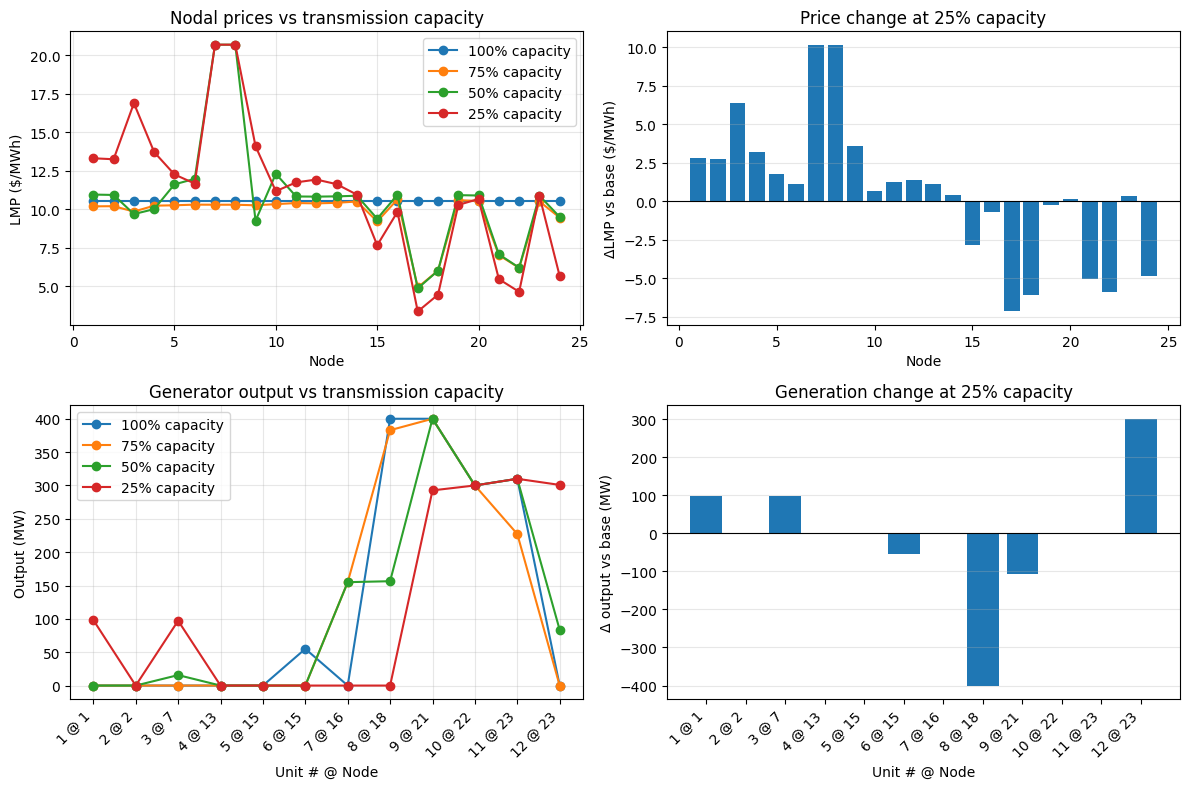

In [49]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Sensitivity: derate line capacity → LMPs + generator output (no battery)
# ---------------------------------------------------------------------------
HOUR = 1
REF_NODE = 1
S_BASE = 100.0
BATTERY_UNIT = 13
BATTERY_LOAD = 18

# --- Market data (battery excluded) ---
demand_hour = units_demand.loc[units_demand["hour"] == HOUR].iloc[0]

load_node_all = demand_distribution.set_index("Load #")["Node"].astype(int).to_dict()
loads = [
    d for d in demand_bids["Load #"].tolist()
    if d in load_node_all and d != BATTERY_LOAD
]
U = {
    d: float(demand_bids.set_index("Load #").loc[d, "Synthetic demand bid ($/MWh)"])
    for d in loads
}
Pbar_D = {d: float(demand_hour[f"Load {d}"]) for d in loads}
load_node = {d: load_node_all[d] for d in loads}

generators = generators_data.merge(
    generators_costs[["Unit #", "C_i ($/MWh)"]], on="Unit #"
)
generators = generators[generators["Unit #"] != BATTERY_UNIT].copy()
units = generators["Unit #"].tolist()
C = generators.set_index("Unit #")["C_i ($/MWh)"].to_dict()
Pmax = generators.set_index("Unit #")["Pmax_i (MW)"].to_dict()
gen_node = generators.set_index("Unit #")["Node"].astype(int).to_dict()

assert BATTERY_LOAD not in loads and BATTERY_UNIT not in units
print(f"Excluded battery Unit #{BATTERY_UNIT} / Load #{BATTERY_LOAD}")
print(f"loads ({len(loads)}): {loads}")
print(f"units ({len(units)}): {units}")

# --- Transmission ---
lines = list(range(len(transmission_data)))
from_n = transmission_data["From"].astype(int).tolist()
to_n = transmission_data["To"].astype(int).tolist()
x_pu = transmission_data["Reactance_pu"].astype(float).tolist()
Fmax0 = transmission_data["Capacity_MVA"].astype(float).tolist()

nodes = sorted(
    set(gen_node.values()) | set(load_node.values()) | set(from_n) | set(to_n)
)
gens_at = {n: [g for g in units if gen_node[g] == n] for n in nodes}
loads_at = {n: [d for d in loads if load_node[d] == n] for n in nodes}
lines_from = {n: [l for l in lines if from_n[l] == n] for n in nodes}
lines_to = {n: [l for l in lines if to_n[l] == n] for n in nodes}


def solve_nodal_opf(Fmax, output_flag=0):
    model = gp.Model("nodal_dcopf")
    model.Params.OutputFlag = output_flag

    p_D = model.addVars(loads, lb=0.0, name="p_D")
    p_G = model.addVars(units, lb=0.0, name="p_G")
    theta = model.addVars(nodes, lb=-GRB.INFINITY, name="theta")
    f = model.addVars(lines, lb=-GRB.INFINITY, name="f")

    for d in loads:
        p_D[d].ub = Pbar_D[d]
    for g in units:
        p_G[g].ub = Pmax[g]

    model.addConstr(theta[REF_NODE] == 0.0)

    for l in lines:
        model.addConstr(
            f[l] == S_BASE * (theta[from_n[l]] - theta[to_n[l]]) / x_pu[l]
        )
        f[l].lb = -float(Fmax[l])
        f[l].ub = float(Fmax[l])

    model.setObjective(
        gp.quicksum(U[d] * p_D[d] for d in loads)
        - gp.quicksum(C[g] * p_G[g] for g in units),
        GRB.MAXIMIZE,
    )

    bal = {}
    for n in nodes:
        bal[n] = model.addConstr(
            gp.quicksum(p_D[d] for d in loads_at[n])
            - gp.quicksum(p_G[g] for g in gens_at[n])
            + gp.quicksum(f[l] for l in lines_from[n])
            - gp.quicksum(f[l] for l in lines_to[n])
            == 0
        )

    model.optimize()
    if model.Status != GRB.OPTIMAL:
        return None

    return {
        "SW": model.ObjVal,
        "LMP": {n: bal[n].Pi for n in nodes},
        "flow": {l: f[l].X for l in lines},
        "p_G": {g: p_G[g].X for g in units},
    }


# --- Base case ---
base = solve_nodal_opf(Fmax0)
assert base is not None
assert BATTERY_UNIT not in base["p_G"]

util = pd.DataFrame({
    "line": lines,
    "From": from_n,
    "To": to_n,
    "Capacity": Fmax0,
    "flow": [base["flow"][l] for l in lines],
})
util["|flow|"] = util["flow"].abs()
util["utilization"] = util["|flow|"] / util["Capacity"]
util = util.sort_values("utilization", ascending=False)

print(f"Base SW: {base['SW']:,.2f} $")
print("Highest-utilization lines (for context):")
display(util.head(10))

# Stress corridors that create an import pocket around nodes 7–8:
#   26: 16–17,  11: 8–9,  12: 8–10,  6: 3–24
LINES_TO_DERATE = [26, 11, 12, 6]
print("Derating lines:", [(from_n[l], to_n[l]) for l in LINES_TO_DERATE])

# --- Capacity sweep ---
factors = [1.0, 0.75, 0.50, 0.25]

rows = []
gen_rows = []
lmp_by_factor = {}
gen_by_factor = {}

for alpha in factors:
    Fmax = list(Fmax0)
    for l in LINES_TO_DERATE:
        Fmax[l] = alpha * Fmax0[l]

    sol = solve_nodal_opf(Fmax)
    if sol is None:
        print(f"Infeasible at factor {alpha}")
        continue

    lmp_by_factor[alpha] = sol["LMP"]
    gen_by_factor[alpha] = sol["p_G"]

    for n in nodes:
        rows.append({
            "capacity_factor": alpha,
            "Node": n,
            "LMP ($/MWh)": sol["LMP"][n],
            "SW ($)": sol["SW"],
            "LMP_delta_vs_base": sol["LMP"][n] - base["LMP"][n],
        })

    for g in units:
        gen_rows.append({
            "capacity_factor": alpha,
            "Unit #": g,
            "Node": gen_node[g],
            "output (MW)": sol["p_G"][g],
            "output_delta_vs_base (MW)": sol["p_G"][g] - base["p_G"][g],
        })

sens = pd.DataFrame(rows)
gen_sens = pd.DataFrame(gen_rows)

lmp_wide = sens.pivot(index="Node", columns="capacity_factor", values="LMP ($/MWh)")
print("Nodal LMPs vs capacity factor of derated line(s):")
display(lmp_wide.round(2))

gen_wide = (
    gen_sens.pivot(index=["Unit #", "Node"], columns="capacity_factor", values="output (MW)")
    .sort_index()
)
print("Generator output (MW) vs capacity factor:")
display(gen_wide.round(2))

print("Social welfare vs capacity factor:")
display(sens.groupby("capacity_factor", as_index=False)["SW ($)"].first())

# --- Plots ---
unit_labels = [f"{g} @ {gen_node[g]}" for g in units]
x_units = range(len(units))
alpha_tight = min(lmp_by_factor)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for alpha in factors:
    if alpha not in lmp_by_factor:
        continue
    axes[0, 0].plot(
        nodes,
        [lmp_by_factor[alpha][n] for n in nodes],
        marker="o",
        label=f"{int(alpha * 100)}% capacity",
    )
axes[0, 0].set_xlabel("Node")
axes[0, 0].set_ylabel("LMP ($/MWh)")
axes[0, 0].set_title("Nodal prices vs transmission capacity")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

delta = [lmp_by_factor[alpha_tight][n] - base["LMP"][n] for n in nodes]
axes[0, 1].bar(nodes, delta)
axes[0, 1].set_xlabel("Node")
axes[0, 1].set_ylabel("ΔLMP vs base ($/MWh)")
axes[0, 1].set_title(f"Price change at {int(alpha_tight * 100)}% capacity")
axes[0, 1].axhline(0, color="k", lw=0.8)
axes[0, 1].grid(True, axis="y", alpha=0.3)

for alpha in factors:
    if alpha not in gen_by_factor:
        continue
    axes[1, 0].plot(
        x_units,
        [gen_by_factor[alpha][g] for g in units],
        marker="o",
        label=f"{int(alpha * 100)}% capacity",
    )
axes[1, 0].set_xticks(list(x_units))
axes[1, 0].set_xticklabels(unit_labels, rotation=45, ha="right")
axes[1, 0].set_xlabel("Unit # @ Node")
axes[1, 0].set_ylabel("Output (MW)")
axes[1, 0].set_title("Generator output vs transmission capacity")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

delta_g = [gen_by_factor[alpha_tight][g] - base["p_G"][g] for g in units]
axes[1, 1].bar(x_units, delta_g)
axes[1, 1].set_xticks(list(x_units))
axes[1, 1].set_xticklabels(unit_labels, rotation=45, ha="right")
axes[1, 1].set_xlabel("Unit # @ Node")
axes[1, 1].set_ylabel("Δ output vs base (MW)")
axes[1, 1].set_title(f"Generation change at {int(alpha_tight * 100)}% capacity")
axes[1, 1].axhline(0, color="k", lw=0.8)
axes[1, 1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In the base case, no lines bind and all nodal prices equal $10.52/MWh, so the network behaves like a copper plate. Derating lines 16–17, 8–9, 8–10, and 3–24 to 75–25% of capacity creates congestion that splits the market: import-constrained nodes 7–8 see LMPs rise to $20.70/MWh (local unit 3), while the export-rich south (e.g. nodes 17–18, 21–22) sees much lower prices as cheap plant—especially unit 8@18—is stranded. Dispatch shifts out of merit (expensive units 1 and 3 turn on; unit 8 falls to zero at 25%), and social welfare drops only slightly at 75% capacity but by about 20% at 25%, showing that nodal prices need not be identical once transmission is scarce.

### Zonal Market Prices

In [50]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd

# ---------------------------------------------------------------------------
# Zonal market clearing (NTC / ATC), single hour, no storage
# ---------------------------------------------------------------------------
HOUR = 1
S_BASE = 100.0  # unused in NTC model (no DC angles); kept for consistency

BATTERY_UNIT = 13
BATTERY_LOAD = 18

# Zones (bus 24 assigned to zone 3 — needed for lines 3–24 and 15–24)
ZONE_OF_NODE = {n: 1 for n in range(1, 11)}
ZONE_OF_NODE.update({n: 2 for n in range(11, 17)})
ZONE_OF_NODE.update({n: 3 for n in range(17, 25)})  # 17–24
zones = sorted(set(ZONE_OF_NODE.values()))

# --- Bids / offers (battery excluded) ---
demand_hour = units_demand.loc[units_demand["hour"] == HOUR].iloc[0]

load_node = demand_distribution.set_index("Load #")["Node"].astype(int).to_dict()
loads = [
    d for d in demand_bids["Load #"].tolist()
    if d in load_node and d != BATTERY_LOAD
]
U = {
    d: float(demand_bids.set_index("Load #").loc[d, "Synthetic demand bid ($/MWh)"])
    for d in loads
}
Pbar_D = {d: float(demand_hour[f"Load {d}"]) for d in loads}

generators = generators_data.merge(
    generators_costs[["Unit #", "C_i ($/MWh)"]], on="Unit #"
)
generators = generators[generators["Unit #"] != BATTERY_UNIT].copy()
units = generators["Unit #"].tolist()
C = generators.set_index("Unit #")["C_i ($/MWh)"].to_dict()
Pmin = generators.set_index("Unit #")["Pmin_i (MW)"].to_dict()
Pmax = generators.set_index("Unit #")["Pmax_i (MW)"].to_dict()
gen_node = generators.set_index("Unit #")["Node"].astype(int).to_dict()
load_node = {d: load_node[d] for d in loads}

gen_zone = {g: ZONE_OF_NODE[gen_node[g]] for g in units}
load_zone = {d: ZONE_OF_NODE[load_node[d]] for d in loads}

assert BATTERY_LOAD not in loads and BATTERY_UNIT not in units

gens_in_zone = {z: [g for g in units if gen_zone[g] == z] for z in zones}
loads_in_zone = {z: [d for d in loads if load_zone[d] == z] for z in zones}

# --- ATC = sum of thermal capacities of all nodal lines between zone pairs ---
ATC = {(a, b): 0.0 for a in zones for b in zones if a < b}
for _, row in transmission_data.iterrows():
    i, j = int(row["From"]), int(row["To"])
    zi, zj = ZONE_OF_NODE[i], ZONE_OF_NODE[j]
    if zi != zj:
        a, b = (zi, zj) if zi < zj else (zj, zi)
        ATC[(a, b)] += float(row["Capacity_MVA"])

zone_pairs = sorted(ATC.keys())
print("Zone definition:", {z: [n for n, zz in ZONE_OF_NODE.items() if zz == z] for z in zones})
print("ATC (MW):", {f"{a}–{b}": ATC[(a, b)] for a, b in zone_pairs})
# Expected with bus 24 in zone 3: 1–2: 1600, 1–3: 400, 2–3: 3500

# --- Model: no nodal balance, no angles ---
model = gp.Model("zonal_ntc_social_welfare")
model.Params.OutputFlag = 0

p_D = model.addVars(loads, lb=0.0, name="p_D")
p_G = model.addVars(units, lb=0.0, name="p_G")
# f[a,b] > 0: net transfer from zone a → zone b
f = model.addVars(zone_pairs, lb=-GRB.INFINITY, name="f_zone")

for d in loads:
    p_D[d].ub = Pbar_D[d]
for g in units:
    p_G[g].ub = Pmax[g]

for a, b in zone_pairs:
    f[a, b].lb = -ATC[(a, b)]
    f[a, b].ub = ATC[(a, b)]

model.setObjective(
    gp.quicksum(U[d] * p_D[d] for d in loads)
    - gp.quicksum(C[g] * p_G[g] for g in units),
    GRB.MAXIMIZE,
)

# Zonal balance (same sign convention as nodal cell):
#   Σ demand_z − Σ gen_z + net_export_z = 0
# net_export_z = Σ_{b>z} f[z,b] − Σ_{a<z} f[a,z]
zonal_balance = {}
for z in zones:
    net_export = gp.quicksum(f[z, b] for a, b in zone_pairs if a == z) - gp.quicksum(
        f[a, z] for a, b in zone_pairs if b == z
    )
    zonal_balance[z] = model.addConstr(
        gp.quicksum(p_D[d] for d in loads_in_zone[z])
        - gp.quicksum(p_G[g] for g in gens_in_zone[z])
        + net_export
        == 0,
        name=f"zonal_balance[{z}]",
    )

model.optimize()
if model.Status != GRB.OPTIMAL:
    raise RuntimeError(f"Model status: {model.Status}")

social_welfare = model.ObjVal
ZMP = {z: zonal_balance[z].Pi for z in zones}  # zonal market prices

zmp_results = pd.DataFrame(
    {"Zone": zones, "ZMP ($/MWh)": [ZMP[z] for z in zones]}
)

transfer_results = pd.DataFrame(
    {
        "From zone": [a for a, b in zone_pairs],
        "To zone": [b for a, b in zone_pairs],
        "ATC (MW)": [ATC[(a, b)] for a, b in zone_pairs],
        "flow From→To (MW)": [f[a, b].X for a, b in zone_pairs],
    }
)
transfer_results["|flow| (MW)"] = transfer_results["flow From→To (MW)"].abs()
transfer_results["utilization"] = (
    transfer_results["|flow| (MW)"] / transfer_results["ATC (MW)"]
)
transfer_results["congested"] = transfer_results["utilization"] > 1 - 1e-5

demand_results = pd.DataFrame(
    {
        "Load #": loads,
        "Node": [load_node[d] for d in loads],
        "Zone": [load_zone[d] for d in loads],
        "bid ($/MWh)": [U[d] for d in loads],
        "max demand (MW)": [Pbar_D[d] for d in loads],
        "cleared (MW)": [p_D[d].X for d in loads],
        "ZMP ($/MWh)": [ZMP[load_zone[d]] for d in loads],
    }
)
demand_results["satisfied"] = demand_results.apply(
    lambda r: "fully"
    if abs(r["cleared (MW)"] - r["max demand (MW)"]) < 1e-6
    else ("partially" if r["cleared (MW)"] > 1e-6 else "not"),
    axis=1,
)

generation_results = pd.DataFrame(
    {
        "Unit #": units,
        "Node": [gen_node[g] for g in units],
        "Zone": [gen_zone[g] for g in units],
        "offer ($/MWh)": [C[g] for g in units],
        "Pmin (MW)": [Pmin[g] for g in units],
        "Pmax (MW)": [Pmax[g] for g in units],
        "output (MW)": [p_G[g].X for g in units],
        "ZMP ($/MWh)": [ZMP[gen_zone[g]] for g in units],
    }
)

print(f"Hour: {HOUR}")
print(f"Social welfare: {social_welfare:,.2f} $")
print(
    f"Zonal prices: "
    + ", ".join(f"Z{z}={ZMP[z]:.2f}" for z in zones)
    + " $/MWh"
)
print(
    f"Congested inter-zonal links: "
    f"{int(transfer_results['congested'].sum())} / {len(zone_pairs)}"
)
print()
print("Zonal market prices:")
display(zmp_results)
print("Inter-zonal transfers (positive = From → To):")
display(transfer_results)
print("Demand clearing:")
display(demand_results)
print("Generator output:")
display(generation_results)

Zone definition: {1: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 2: [11, 12, 13, 14, 15, 16], 3: [17, 18, 19, 20, 21, 22, 23, 24]}
ATC (MW): {'1–2': 1600.0, '1–3': 400.0, '2–3': 3500.0}
Hour: 1
Social welfare: 19,392.71 $
Zonal prices: Z1=10.52, Z2=10.52, Z3=10.52 $/MWh
Congested inter-zonal links: 1 / 3

Zonal market prices:


,Zone,ZMP ($/MWh)
0,1,10.52
1,2,10.52
2,3,10.52


Inter-zonal transfers (positive = From → To):


,From zone,To zone,ATC (MW),flow From→To (MW),|flow| (MW),utilization,congested
0,1,2,1600.0,-283.696475,283.696475,0.177310,False
1,1,3,400.0,-400.000000,400.000000,1.000000,True
2,2,3,3500.0,-353.725165,353.725165,0.101064,False


Demand clearing:


,Load #,Node,Zone,bid ($/MWh),max demand (MW),cleared (MW),ZMP ($/MWh),satisfied
0,1,1,1,14.50,67.481730,67.481730,10.52,fully
1,2,2,1,6.02,60.378390,0.000000,10.52,not
2,3,3,1,27.32,111.877605,111.877605,10.52,fully
3,4,4,1,18.94,46.171710,46.171710,10.52,fully
4,5,5,1,11.00,44.395875,44.395875,10.52,fully
5,6,6,1,8.72,85.240080,0.000000,10.52,not
6,7,7,1,30.00,78.136740,78.136740,10.52,fully
7,8,8,1,23.46,106.550100,106.550100,10.52,fully
8,9,9,1,14.10,108.325935,108.325935,10.52,fully
9,10,10,1,15.00,120.756780,120.756780,10.52,fully


Generator output:


,Unit #,Node,Zone,offer ($/MWh),Pmin (MW),Pmax (MW),output (MW),ZMP ($/MWh)
0,1,1,1,13.32,30.40,152.0,0.000000,10.52
1,2,2,1,13.32,30.40,152.0,0.000000,10.52
2,3,7,1,20.70,75.00,350.0,0.000000,10.52
3,4,13,2,20.93,206.85,591.0,0.000000,10.52
4,5,15,2,26.11,12.00,60.0,0.000000,10.52
5,6,15,2,10.52,54.25,155.0,155.000000,10.52
6,7,16,2,10.52,54.25,155.0,155.000000,10.52
7,8,18,3,6.02,100.00,400.0,400.000000,10.52
8,9,21,3,5.47,100.00,400.0,400.000000,10.52
9,10,22,3,0.00,300.00,300.0,300.000000,10.52


In the zonal NTC clearing for hour 1, zone 3 is strongly export-rich (~754 MW net surplus from cheap southern plant) while zone 1 is deeply import-dependent (~684 MW net deficit and no cleared local generation), so power must move north. The zone 1–3 interface (ATC 400 MW on line 3–24) is fully saturated, while 1–2 and 2–3 stay far below ATC (~18% and ~10%); remaining imports into zone 1 are routed via zone 2, so the 1–3 limit binds thermally but does not split prices; all three ZMPs stay at $10.52/MWh, matching every nodal LMP in the unconstrained DC OPF, and social welfare is the same in both frameworks (~$19,393).

Because prices coincide and the inframarginal schedules that earn rent are unchanged, profits are unaffected: renewables (wind unit 10 at C = 0) and the cheap conventional south (units 8–9) keep the same output and the same profit (~$3,156, $1,800 and $2,020), while units 6, 7 and 11 sit at C = λ = $10.52 so their profit stays zero even though zonal clearing redistributes their MW (more on 6–7, less on 11). Expensive units remain offline in both cases.

Intra-zonal feasibility / re-dispatch: the zonal model only enforces inter-zonal ATC and treats each zone as a copper plate, so line limits inside zones are not guaranteed. Relative to the network-feasible nodal dispatch, the zonal schedule moves about 255 MW one-sided among units 6, 7 and 11 (total absolute shift ~510 MW) within zones 2–3—enough to change flows on busy southern/central corridors (e.g. around 15–16–17–23, where nodal utilization on 16–17 was already ~79%). That ~255 MW generation reshuffle is a lower-bound sense of the ex-post re-dispatch that may be needed to restore a DC-feasible point if the zonal injections overload intra-zonal lines; inter-zonal ATC itself is already respected by the NTC clearing.

# STEP 4: Balancing Market

Building upon the model in Step 1 (no storage, no transmission network, 1 hour), assume there is an unexpected failure (outage) in one of the conventional generators. The winf farm production is higher than its day-ahead forecast (e.g., 10%). A subset of conventional generators are potential balancing service providers Demands are not flexible. 

Each flexible conventional generator offers upward regulation service at a price equal to the day-ahead price plus 10% of its production cost. Similarly, it offers downward regulation service at a price equal to the day-ahead price minus 15% of its production cost. The load curtailment cost is e500/MWh.

Clearing the balancing market for the given hour and derive the balancing price. Then, calculate the total profit (in both day-ahead and balancing markets) of all conventional generators and wind farms in the given hour

In [51]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd

# --- DA schedule (fixed) ---
p_DA = p_DA_cp
d_DA = d_DA_cp
lam_DA = lam_DA_cp
units = units_DA_cp
C = C_DA_cp
Pmax = Pmax_DA_cp

RU = generators_data.set_index("Unit #")["RU_i (MW/h)"].astype(float).to_dict()
RD = generators_data.set_index("Unit #")["RD_i (MW/h)"].astype(float).to_dict()
R_up = generators_data.set_index("Unit #")["R+_i (MW)"].astype(float).to_dict()

# Flexible conventional providers: have upward reserve capability; unit 7 is out
flex = [g for g in units if g != 7 and R_up.get(g, 0) > 0]

# Realized imbalance (MW): + = shortage
DELTA = (
    p_DA[7]                 # unit 7 fully out
    + 0.15 * p_DA[9]        # unit 9: −15%
    - 0.10 * p_DA[8]        # unit 8: +10%
    - 0.10 * p_DA[10]       # unit 10: +10%
)

# Regulation offer prices ($/MWh) — production cost = C_i, NOT C^su_i
C_up = {g: lam_DA + 0.10 * C[g] for g in flex}
C_dn = {g: lam_DA - 0.15 * C[g] for g in flex}
VOLL = 500.0  # load curtailment ($/MWh)

bal = gp.Model("balancing_market")
bal.Params.OutputFlag = 0

p_up = bal.addVars(flex, lb=0.0, name="p_up")
p_dn = bal.addVars(flex, lb=0.0, name="p_dn")
p_curt = bal.addVar(lb=0.0, ub=sum(d_DA.values()), name="p_curt")

for g in flex:
    # Ramp + capacity / DA schedule (do not read .ub back)
    p_up[g].ub = min(RU[g], max(Pmax[g] - p_DA[g], 0.0))
    p_dn[g].ub = min(RD[g], max(p_DA[g], 0.0))

# Cost min: upward (+), curtailment (+), downward (−) — same sign convention as the slide
bal.setObjective(
    gp.quicksum(C_up[g] * p_up[g] for g in flex)
    + VOLL * p_curt
    - gp.quicksum(C_dn[g] * p_dn[g] for g in flex),
    GRB.MINIMIZE,
)

balance_rt = bal.addConstr(
    gp.quicksum(p_up[g] for g in flex) + p_curt
    - gp.quicksum(p_dn[g] for g in flex)
    == DELTA,
    name="balancing_equality",
)

bal.optimize()

balancing_price = balance_rt.Pi
balancing_cost = bal.ObjVal

reg_results = pd.DataFrame(
    {
        "Unit #": flex,
        "p_DA (MW)": [p_DA[g] for g in flex],
        "C_up ($/MWh)": [C_up[g] for g in flex],
        "C_dn ($/MWh)": [C_dn[g] for g in flex],
        "up (MW)": [p_up[g].X for g in flex],
        "down (MW)": [p_dn[g].X for g in flex],
        "RU (MW/h)": [RU[g] for g in flex],
        "RD (MW/h)": [RD[g] for g in flex],
    }
)

print(f"Hour: {HOUR}")
print(f"DA price λ: {lam_DA:.2f} $/MWh")
print(f"Imbalance Δ: {DELTA:.2f} MW  (+ = shortage)")
print(f"Balancing cost: {balancing_cost:,.2f} $")
print(f"Balancing price λ^Bal: {balancing_price:.2f} $/MWh")
print(f"Load curtailment: {p_curt.X:.2f} MW")
display(reg_results.loc[(reg_results["up (MW)"] > 1e-6) | (reg_results["down (MW)"] > 1e-6)])

Hour: 1
DA price λ: 10.52 $/MWh
Imbalance Δ: 145.00 MW  (+ = shortage)
Balancing cost: 1,677.94 $
Balancing price λ^Bal: 11.57 $/MWh
Load curtailment: 0.00 MW


,Unit #,p_DA (MW),C_up ($/MWh),C_dn ($/MWh),up (MW),down (MW),RU (MW/h),RD (MW/h)
5,6,0.0,11.572,8.942,145.0,0.0,155.0,155.0


In STEP 5 the copper-plate day-ahead schedule from STEP 1 is held fixed and a real-time balancing market is cleared for hour 1 after several delivery shocks: unit 7 is fully out, unit 9 produces 15% less than scheduled, and units 8 and 10 produce 10% more. These events create a net system shortage of 145 MW. Only flexible conventional units (positive upward reserve capability, excluding the failed unit 7) may offer balancing energy, with upward offers at the day-ahead price plus 10% of production cost and downward offers at the day-ahead price minus 15% of production cost; load curtailment is available at 500 USD/MWh as a last resort. The balancing problem minimizes regulation cost (upward and curtailment positive, downward negative in the objective), subject to covering the 145 MW imbalance and to ramp and capacity limits tied to the day-ahead schedule. The optimal solution activates 145 MW of upward regulation from unit 6 at about 11.57 USD/MWh, with no downward regulation and no curtailment, so the balancing price equals that marginal upward offer and the balancing cost is about 1677.94 USD. Producer profits are then evaluated over both markets under a one-price scheme (all deviations settled at the balancing price) and under a two-price scheme (helping deviations settled at the day-ahead price, aggravating deviations at the balancing price). Overall, STEP 5 shows that the imbalance can be resolved with flexible conventional capacity alone, that the balancing price rises only modestly above the day-ahead price of 10.52 USD/MWh, and that the settlement rule (one-price vs two-price) mainly redistributes profits between helpers and aggravators rather than changing the physical dispatch.

## Profits under one-price scheme

In [52]:
import pandas as pd

lam_DA = lam_DA_cp
lam_Bal = float(balancing_price)

# Cleared balancing volumes (0 if not in flex)
up = {g: float(p_up[g].X) if g in p_up else 0.0 for g in units_DA_cp}
dn = {g: float(p_dn[g].X) if g in p_dn else 0.0 for g in units_DA_cp}

rows = []
for g in units_DA_cp:
    p0 = p_DA_cp[g]
    Cg = C_DA_cp[g]

    # Realized RT output
    if g == 7:
        p_rt = 0.0
    elif g == 9:
        p_rt = 0.85 * p0
    elif g in (8, 10):
        p_rt = 1.10 * p0
    else:
        p_rt = p0 + up[g] - dn[g]

    dev = p_rt - p0  # >0 long / upward; <0 short / downward

    profit_DA = (lam_DA - Cg) * p0
    profit_Bal = (lam_Bal - Cg) * dev
    profit_tot = profit_DA + profit_Bal
    # same as: lam_DA*p0 + lam_Bal*dev - Cg*p_rt

    kind = "wind" if g == 10 else "conventional"
    rows.append(
        {
            "Unit #": g,
            "type": kind,
            "p_DA (MW)": p0,
            "p_RT (MW)": p_rt,
            "deviation (MW)": dev,
            "profit DA ($)": profit_DA,
            "profit Bal ($)": profit_Bal,
            "profit total ($)": profit_tot,
        }
    )

profit_df = pd.DataFrame(rows)
display(profit_df)

print("Total profit — all producers: "
      f"{profit_df['profit total ($)'].sum():,.2f} $")
print("  conventional: "
      f"{profit_df.loc[profit_df['type']=='conventional', 'profit total ($)'].sum():,.2f} $")
print("  wind:         "
      f"{profit_df.loc[profit_df['type']=='wind', 'profit total ($)'].sum():,.2f} $")

,Unit #,type,p_DA (MW),p_RT (MW),deviation (MW),profit DA ($),profit Bal ($),profit total ($)
0,1,conventional,0.000000,0.000000,0.0,-0.0,-0.00,-0.00
1,2,conventional,0.000000,0.000000,0.0,-0.0,-0.00,-0.00
2,3,conventional,0.000000,0.000000,0.0,-0.0,-0.00,-0.00
3,4,conventional,0.000000,0.000000,0.0,-0.0,-0.00,-0.00
4,5,conventional,0.000000,0.000000,0.0,-0.0,-0.00,-0.00
5,6,conventional,0.000000,145.000000,145.0,0.0,152.54,152.54
6,7,conventional,155.000000,0.000000,-155.0,0.0,-163.06,-163.06
7,8,conventional,400.000000,440.000000,40.0,1800.0,222.08,2022.08
8,9,conventional,400.000000,340.000000,-60.0,2020.0,-366.12,1653.88
9,10,wind,300.000000,330.000000,30.0,3156.0,347.16,3503.16


Total profit — all producers: 7,168.60 $
  conventional: 3,665.44 $
  wind:         3,503.16 $


## Profits under two-prices scheme

In [53]:
import pandas as pd

lam_DA = lam_DA_cp
lam_Bal = float(balancing_price)
DELTA = float(DELTA)  # system imbalance (+ = shortage)

up = {g: float(p_up[g].X) if g in p_up else 0.0 for g in units_DA_cp}
dn = {g: float(p_dn[g].X) if g in p_dn else 0.0 for g in units_DA_cp}

rows = []
for g in units_DA_cp:
    p0 = p_DA_cp[g]
    Cg = C_DA_cp[g]

    if g == 7:
        p_rt = 0.0
    elif g == 9:
        p_rt = 0.85 * p0
    elif g in (8, 10):
        p_rt = 1.10 * p0
    else:
        p_rt = p0 + up[g] - dn[g]

    dev = p_rt - p0  # δ

    # Two-price imbalance price
    if abs(dev) < 1e-9 or abs(DELTA) < 1e-9:
        lam_imb = lam_DA
        side = "none"
    elif dev * DELTA < 0:
        lam_imb = lam_Bal   # aggravating
        side = "aggravating"
    else:
        lam_imb = lam_DA    # helping
        side = "helping"

    profit_DA = lam_DA * p0 - Cg * p0
    # bal part only: replace one-price λ_Bal*δ with λ_imb*δ,
    # and move cost of deviation into total via C*p_rt
    profit_tot = lam_DA * p0 + lam_imb * dev - Cg * p_rt
    profit_Bal = profit_tot - profit_DA

    rows.append(
        {
            "Unit #": g,
            "type": "wind" if g == 10 else "conventional",
            "p_DA (MW)": p0,
            "p_RT (MW)": p_rt,
            "deviation (MW)": dev,
            "side": side,
            "λ_imb ($/MWh)": lam_imb,
            "profit DA ($)": profit_DA,
            "profit Bal ($)": profit_Bal,
            "profit total ($)": profit_tot,
        }
    )

profit_two = pd.DataFrame(rows)
display(profit_two)

print("TWO-PRICE — total profit all producers: "
      f"{profit_two['profit total ($)'].sum():,.2f} $")
print("  conventional: "
      f"{profit_two.loc[profit_two.type=='conventional', 'profit total ($)'].sum():,.2f} $")
print("  wind:         "
      f"{profit_two.loc[profit_two.type=='wind', 'profit total ($)'].sum():,.2f} $")

,Unit #,type,p_DA (MW),p_RT (MW),deviation (MW),side,λ_imb ($/MWh),profit DA ($),profit Bal ($),profit total ($)
0,1,conventional,0.000000,0.000000,0.0,none,10.520,0.0,0.00,0.00
1,2,conventional,0.000000,0.000000,0.0,none,10.520,0.0,0.00,0.00
2,3,conventional,0.000000,0.000000,0.0,none,10.520,0.0,0.00,0.00
3,4,conventional,0.000000,0.000000,0.0,none,10.520,0.0,0.00,0.00
4,5,conventional,0.000000,0.000000,0.0,none,10.520,0.0,0.00,0.00
5,6,conventional,0.000000,145.000000,145.0,helping,10.520,0.0,0.00,0.00
6,7,conventional,155.000000,0.000000,-155.0,aggravating,11.572,0.0,-163.06,-163.06
7,8,conventional,400.000000,440.000000,40.0,helping,10.520,1800.0,180.00,1980.00
8,9,conventional,400.000000,340.000000,-60.0,aggravating,11.572,2020.0,-366.12,1653.88
9,10,wind,300.000000,330.000000,30.0,helping,10.520,3156.0,315.60,3471.60


TWO-PRICE — total profit all producers: 6,942.42 $
  conventional: 3,470.82 $
  wind:         3,471.60 $


# STEP 6: Reserve Market

Assuming the TSO has determined that the upward reserve services to be procured in the reserve market is 15% of the total demand in the corresponding hour. This value is 10% for the downward reserve services. Considering the same subset of conventional generators in Step 5 as flexible resources.

Clearing the reserve and day-ahead markets sequentially, following the current practice in European electricity markets, and report the market-clearing prices for reserve and electricity.

## Reserve Market stage

In [55]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd

HOUR = 1

# System demand for this hour (forecast) — reserve cleared BEFORE DA
D_h = float(load_profile.loc[load_profile["Hour"] == HOUR, "System demand (MW)"].iloc[0])
R_UP_REQ = 0.15 * D_h
R_DN_REQ = 0.10 * D_h

generators = generators_data.merge(
    generators_costs[["Unit #", "C_i ($/MWh)", "C+_i ($/MWh)", "C-_i ($/MWh)"]],
    on="Unit #",
)
# drop battery if it was added earlier
if "BATTERY_UNIT" in dir():
    generators = generators[generators["Unit #"] != BATTERY_UNIT].copy()

units = generators["Unit #"].tolist()
C = generators.set_index("Unit #")["C_i ($/MWh)"].astype(float).to_dict()
C_plus = generators.set_index("Unit #")["C+_i ($/MWh)"].astype(float).to_dict()
C_minus = generators.set_index("Unit #")["C-_i ($/MWh)"].astype(float).to_dict()
Pmax = generators.set_index("Unit #")["Pmax_i (MW)"].astype(float).to_dict()
Pmin = generators.set_index("Unit #")["Pmin_i (MW)"].astype(float).to_dict()
R_plus_max = generators.set_index("Unit #")["R+_i (MW)"].astype(float).to_dict()
R_minus_max = generators.set_index("Unit #")["R-_i (MW)"].astype(float).to_dict()

flex = [g for g in units if R_plus_max[g] > 0]  # same flexible conventional subset

# --- Reserve market: minimize procurement cost ---
m_res = gp.Model("reserve_market")
m_res.Params.OutputFlag = 0

r_up = m_res.addVars(flex, lb=0.0, name="r_up")
r_dn = m_res.addVars(flex, lb=0.0, name="r_dn")

for g in flex:
    r_up[g].ub = R_plus_max[g]
    r_dn[g].ub = R_minus_max[g]
    # optional: cannot sell more reserve than capacity
    m_res.addConstr(r_up[g] + r_dn[g] <= Pmax[g], name=f"res_cap[{g}]")

m_res.addConstr(gp.quicksum(r_up[g] for g in flex) >= R_UP_REQ, name="req_up")
m_res.addConstr(gp.quicksum(r_dn[g] for g in flex) >= R_DN_REQ, name="req_dn")

m_res.setObjective(
    gp.quicksum(C_plus[g] * r_up[g] + C_minus[g] * r_dn[g] for g in flex),
    GRB.MINIMIZE,
)
m_res.optimize()

r_up_star = {g: float(r_up[g].X) for g in flex}
r_dn_star = {g: float(r_dn[g].X) for g in flex}
# non-flexible: zero reserve
for g in units:
    r_up_star.setdefault(g, 0.0)
    r_dn_star.setdefault(g, 0.0)

reserve_results = pd.DataFrame(
    {
        "Unit #": flex,
        "C+ ($/MW)": [C_plus[g] for g in flex],
        "C- ($/MW)": [C_minus[g] for g in flex],
        "R+_max (MW)": [R_plus_max[g] for g in flex],
        "R-_max (MW)": [R_minus_max[g] for g in flex],
        "r+ cleared (MW)": [r_up_star[g] for g in flex],
        "r- cleared (MW)": [r_dn_star[g] for g in flex],
    }
)

# Cleared reserve prices = duals of the requirement constraints
# (shadow price of one extra MW of required reserve)
lam_R_up = m_res.getConstrByName("req_up").Pi    # $/MW for upward reserve
lam_R_dn = m_res.getConstrByName("req_dn").Pi    # $/MW for downward reserve

procured_up = sum(r_up_star[g] for g in flex)
procured_dn = sum(r_dn_star[g] for g in flex)

tol = 1e-6
up_ok = procured_up + tol >= R_UP_REQ
dn_ok = procured_dn + tol >= R_DN_REQ

print(f"Hour: {HOUR}")
print(f"System demand D_h: {D_h:.3f} MW")
print(f"Upward requirement (15%):   {R_UP_REQ:.3f} MW")
print(f"Downward requirement (10%): {R_DN_REQ:.3f} MW")
print()
print(f"Procured upward reserve:   {procured_up:.3f} MW  →  "
      f"{'FULFILLED' if up_ok else 'NOT fulfilled'}")
print(f"Procured downward reserve: {procured_dn:.3f} MW  →  "
      f"{'FULFILLED' if dn_ok else 'NOT fulfilled'}")
print()
print(f"Cleared upward reserve price   λ_R+: {lam_R_up:.2f} $/MW")
print(f"Cleared downward reserve price λ_R-: {lam_R_dn:.2f} $/MW")
print(f"Reserve procurement cost: {m_res.ObjVal:,.2f} $")
print(f"Model status: {m_res.Status} "
      f"({'OPTIMAL' if m_res.Status == GRB.OPTIMAL else 'NOT OPTIMAL'})")
display(reserve_results.loc[
    (reserve_results["r+ cleared (MW)"] > 1e-6)
    | (reserve_results["r- cleared (MW)"] > 1e-6)
])

Hour: 1
System demand D_h: 1775.835 MW
Upward requirement (15%):   266.375 MW
Downward requirement (10%): 177.584 MW

Procured upward reserve:   266.375 MW  →  FULFILLED
Procured downward reserve: 177.584 MW  →  FULFILLED

Cleared upward reserve price   λ_R+: 24.00 $/MW
Cleared downward reserve price λ_R-: 11.00 $/MW
Reserve procurement cost: 5,686.42 $
Model status: 2 (OPTIMAL)


,Unit #,C+ ($/MW),C- ($/MW),R+_max (MW),R-_max (MW),r+ cleared (MW),r- cleared (MW)
0,1,15.0,11.0,40.0,40.0,40.00000,17.5835
1,2,15.0,11.0,40.0,40.0,40.00000,0.0000
2,3,24.0,16.0,70.0,70.0,26.37525,0.0000
5,6,16.0,7.0,30.0,30.0,30.00000,30.0000
6,7,16.0,7.0,30.0,30.0,30.00000,30.0000
7,11,14.0,8.0,60.0,60.0,60.00000,60.0000
8,12,16.0,8.0,40.0,40.0,40.00000,40.0000


## Day-Ahead stage

In [ ]:
# Demand bids (same as your cell)
demand_hour = units_demand.loc[units_demand["hour"] == HOUR].iloc[0]
loads = demand_bids["Load #"].tolist()
U = demand_bids.set_index("Load #")["Synthetic demand bid ($/MWh)"].to_dict()
Pbar_D = {d: float(demand_hour[f"Load {d}"]) for d in loads}

m_da = gp.Model("da_after_reserve")
m_da.Params.OutputFlag = 0

p_D = m_da.addVars(loads, lb=0.0, name="p_D")
p_G = m_da.addVars(units, lb=0.0, name="p_G")

for d in loads:
    p_D[d].ub = Pbar_D[d]

for g in units:
    # Capacity reserved for upward reserve cannot be offered in DA
    p_G[g].ub = max(Pmax[g] - r_up_star[g], 0.0)
    # Downward reserve requires enough scheduled output
    if r_dn_star[g] > 1e-9:
        m_da.addConstr(p_G[g] >= r_dn_star[g], name=f"dn_sched[{g}]")

m_da.setObjective(
    gp.quicksum(U[d] * p_D[d] for d in loads)
    - gp.quicksum(C[g] * p_G[g] for g in units),
    GRB.MAXIMIZE,
)

balance = m_da.addConstr(
    gp.quicksum(p_D[d] for d in loads) - gp.quicksum(p_G[g] for g in units) == 0,
    name="power_balance",
)
m_da.optimize()

market_clearing_price = balance.Pi
social_welfare = m_da.ObjVal

demand_results = pd.DataFrame(
    {
        "Load #": loads,
        "bid ($/MWh)": [U[d] for d in loads],
        "max demand (MW)": [Pbar_D[d] for d in loads],
        "cleared (MW)": [p_D[d].X for d in loads],
    }
)
generation_results = pd.DataFrame(
    {
        "Unit #": units,
        "offer ($/MWh)": [C[g] for g in units],
        "Pmax (MW)": [Pmax[g] for g in units],
        "r+ (MW)": [r_up_star[g] for g in units],
        "r- (MW)": [r_dn_star[g] for g in units],
        "DA cap (MW)": [Pmax[g] - r_up_star[g] for g in units],
        "output (MW)": [p_G[g].X for g in units],
    }
)

print(f"DA social welfare: {social_welfare:,.2f} $")
print(f"DA price λ: {market_clearing_price:.2f} $/MWh")
display(generation_results)

# Snapshot for later balancing / profits
p_DA_cp = {g: float(p_G[g].X) for g in units}
d_DA_cp = {d: float(p_D[d].X) for d in loads}
lam_DA_cp = float(market_clearing_price)
r_up_cp, r_dn_cp = dict(r_up_star), dict(r_dn_star)
units_DA_cp, C_DA_cp, Pmax_DA_cp = list(units), dict(C), dict(Pmax)

DA social welfare: 19,328.68 $
DA price λ: 10.52 $/MWh


,Unit #,offer ($/MWh),Pmax (MW),r+ (MW),r- (MW),DA cap (MW),output (MW)
0,1,13.32,152.0,40.00000,17.5835,112.00000,17.583500
1,2,13.32,152.0,40.00000,0.0000,112.00000,0.000000
2,3,20.70,350.0,26.37525,0.0000,323.62475,0.000000
3,4,20.93,591.0,0.00000,0.0000,591.00000,0.000000
4,5,26.11,60.0,0.00000,0.0000,60.00000,0.000000
5,6,10.52,155.0,30.00000,30.0000,125.00000,122.480375
6,7,10.52,155.0,30.00000,30.0000,125.00000,125.000000
7,8,6.02,400.0,0.00000,0.0000,400.00000,400.000000
8,9,5.47,400.0,0.00000,0.0000,400.00000,400.000000
9,10,0.00,300.0,0.00000,0.0000,300.00000,300.000000


In STEP 6 the market is cleared sequentially: a reserve market first, then the day-ahead energy market, still on a copper-plate system for a single hour. Upward and downward reserve requirements are set to 15% and 10% of hour-1 system demand (about 1775.8 MW), i.e. roughly 266.4 MW of upward and 177.6 MW of downward reserve, and only the flexible conventional units (those with positive upward reserve capability R+, excluding must-run/wind units 8-10) may offer reserve at their capacity prices C+ / C- and caps R+ / R-. The reserve auction minimizes procurement cost subject to meeting both requirements; when the model is optimal, procured volumes meet or exceed the targets, so the reserve needs are fulfilled, and the duals of the requirement constraints give the uniform cleared reserve prices for upward and downward reserve. Capacity awarded in the reserve market is then withdrawn from the day-ahead offer: each unit's DA upper bound becomes Pmax minus its cleared upward reserve, and any downward reserve forces scheduled output to be at least that downward amount, so the same megawatt cannot be sold twice. Re-clearing the DA social-welfare problem under these tightened bounds changes individual schedules relative to unconstrained STEP 1, but the day-ahead price remains 10.52 USD/MWh, because a large block of energy is still available at that marginal offer (units 6, 7 and 11): reserve locking reduces headroom but does not push the system onto the next, more expensive offers (10.89 or 13.32 USD/MWh). Overall, STEP 6 shows that progressive clearing successfully procures the required reserves and couples them into DA through exclusive capacity, while the energy price can stay unchanged when the merit-order margin is thick at the original clearing offer.